# Model 2 - ConvNeXt-B + Mamba + Dynamic Hypergraph
## Wound Image Segmentation

**Architecture:**
- Encoder: ConvNeXt-B (ImageNet pre-trained), 4x4 patch tokenisation, depthwise conv features
- Bottleneck: Mamba state-space block for long-range context
- Graph nodes: Intensity nodes (pixel statistics), Texture nodes (LBP + Gabor), Position nodes (spatial coordinate encoding)
- Dynamic hypergraph: hyperedges updated every forward pass via cosine similarity
- HGNN: spectral convolution on hyperedge incidence matrix
- Decoder: Feature Pyramid Network (FPN) with segmentation head
- Loss: Focal + Dice
- Training: AdamW, linear warmup + cosine annealing, EMA (decay=0.999), gradient clipping
- Augmentation: random flip, rotation, colour jitter, elastic deformation
- Inference: 6-fold Test-Time Augmentation
- Data: Foot Ulcer Segmentation Challenge + Medetec foot ulcer, stratified 70/15/15 split

## 1. Imports and Configuration

In [1]:
import os
import math
import json
import random
import warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.models import ConvNeXt_Base_Weights
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import StratifiedKFold
from scipy.ndimage import binary_erosion

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Configuration
DATA_BASE       = "/kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data"
IMG_SIZE        = 512
NUM_PATCHES     = 128         # number of graph nodes (patches)
PATCH_SIZE      = 4           # 4x4 patch tokenisation
NODE_DIM        = 256         # node embedding dimension
NUM_EPOCHS      = 50
BATCH_SIZE      = 4
LR              = 1e-4
WARMUP_EPOCHS   = 5
EMA_DECAY       = 0.999
PATIENCE        = 10
DROPOUT_RATE    = 0.1
HE_THRESHOLD    = 0.6         # cosine similarity threshold for dynamic hyperedges
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device  : {DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Seed    : {SEED}")


Device  : cuda
PyTorch : 2.10.0+cu128
Seed    : 42


## 2. Dataset Discovery

In [2]:
def _find_dir(base, keyword):
    if not os.path.isdir(base): return None
    for name in sorted(os.listdir(base)):
        if keyword.lower() in name.lower() and os.path.isdir(os.path.join(base, name)):
            return os.path.join(base, name)
    return None

_FUSC = _find_dir(DATA_BASE, "Foot Ulcer")
_MED  = _find_dir(DATA_BASE, "Medetec")

print(f"DATA_BASE : {DATA_BASE}")
print(f"FUSC root : {_FUSC}  ({'found' if _FUSC else 'NOT FOUND'})")
print(f"MED  root : {_MED}   ({'found' if _MED  else 'NOT FOUND'})")
print("\nAll folders inside DATA_BASE:")
for name in sorted(os.listdir(DATA_BASE)):
    print(f"  {name}")

assert _FUSC is not None, f"Could not find Foot Ulcer dataset under {DATA_BASE}"
assert _MED  is not None, f"Could not find Medetec dataset under {DATA_BASE}"

def _lbl(p): return p if os.path.isdir(p) else None

FOLDER_PAIRS = [
    (os.path.join(_FUSC, "train",      "images"), _lbl(os.path.join(_FUSC, "train",      "labels"))),
    (os.path.join(_FUSC, "validation", "images"), _lbl(os.path.join(_FUSC, "validation", "labels"))),
    (os.path.join(_FUSC, "test",       "images"), _lbl(os.path.join(_FUSC, "test",       "labels"))),
    (os.path.join(_MED,  "train",      "images"), _lbl(os.path.join(_MED,  "train",      "labels"))),
    (os.path.join(_MED,  "test",       "images"), _lbl(os.path.join(_MED,  "test",       "labels"))),
]

print("\nFolder pair check:")
for img_d, lbl_d in FOLDER_PAIRS:
    img_ok = os.path.isdir(img_d)
    n      = len([f for f in os.listdir(img_d)
                  if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))]) if img_ok else 0
    lbl_s  = f"labels: {len(os.listdir(lbl_d))} files" if lbl_d else "labels: none"
    print(f"  [{'OK' if img_ok else 'MISSING'}] {img_d}  |  images={n}  |  {lbl_s}")


DATA_BASE : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data
FUSC root : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge  (found)
MED  root : /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Medetec_foot_ulcer_224   (found)

All folders inside DATA_BASE:
  Foot Ulcer Segmentation Challenge
  Medetec_foot_ulcer_224
  wound_dataset

Folder pair check:
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/train/images  |  images=810  |  labels: 810 files
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/validation/images  |  images=200  |  labels: 200 files
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Foot Ulcer Segmentation Challenge/test/images  |  images=200  |  labels: none
  [OK] /kaggle/input/datasets/adnanjan01/wound-seg-3-datasets/data/Medetec_foot_ulcer_224/train/images  |  images=152  |  labels

## 3. Dataset

In [3]:
class TrainAugmentation:
    def __init__(self, img_size=IMG_SIZE):
        self.img_size = img_size

    def __call__(self, img_np, mask_np):
        if random.random() < 0.5:
            img_np = np.fliplr(img_np).copy(); mask_np = np.fliplr(mask_np).copy()
        if random.random() < 0.5:
            img_np = np.flipud(img_np).copy(); mask_np = np.flipud(mask_np).copy()
        k = random.randint(0, 3)
        if k: img_np = np.rot90(img_np, k).copy(); mask_np = np.rot90(mask_np, k).copy()
        if random.random() < 0.3:
            h, w = img_np.shape[:2]; gs = 20
            dx = cv2.GaussianBlur((np.random.rand(h//gs+1, w//gs+1)*2-1).astype(np.float32),(0,0),3)
            dy = cv2.GaussianBlur((np.random.rand(h//gs+1, w//gs+1)*2-1).astype(np.float32),(0,0),3)
            dx = cv2.resize(dx,(w,h))*20; dy = cv2.resize(dy,(w,h))*20
            x,y = np.meshgrid(np.arange(w),np.arange(h))
            mx = np.clip(x+dx,0,w-1).astype(np.float32); my = np.clip(y+dy,0,h-1).astype(np.float32)
            img_np  = cv2.remap(img_np, mx, my, cv2.INTER_LINEAR)
            mask_np = cv2.remap(mask_np,mx, my, cv2.INTER_NEAREST)
        if random.random() < 0.5:
            p = Image.fromarray(img_np)
            p = transforms.functional.adjust_brightness(p, random.uniform(0.8,1.2))
            p = transforms.functional.adjust_contrast(p,   random.uniform(0.8,1.2))
            p = transforms.functional.adjust_saturation(p, random.uniform(0.8,1.2))
            img_np = np.array(p)
        return img_np, mask_np


class _SingleFolderDataset(Dataset):
    EXTS = (".jpg",".jpeg",".png",".bmp")
    def __init__(self, img_dir, lbl_dir, img_size=IMG_SIZE, augment=False):
        self.img_dir  = img_dir
        self.lbl_dir  = lbl_dir if (lbl_dir and os.path.isdir(lbl_dir)) else None
        self.img_size = img_size
        self.aug_fn   = TrainAugmentation(img_size) if augment else None
        self.ids = sorted([f for f in os.listdir(img_dir) if f.lower().endswith(self.EXTS)])
        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
        ])
    def __len__(self): return len(self.ids)

    def _fg_crop(self, img_np, mask_np):
        ys,xs = np.where(mask_np>0)
        if not len(ys): return img_np, mask_np
        pad=10; h,w=mask_np.shape
        return img_np[max(0,ys.min()-pad):min(h,ys.max()+pad),
                      max(0,xs.min()-pad):min(w,xs.max()+pad)],                mask_np[max(0,ys.min()-pad):min(h,ys.max()+pad),
                       max(0,xs.min()-pad):min(w,xs.max()+pad)]

    def __getitem__(self, idx):
        fname = self.ids[idx]; stem = os.path.splitext(fname)[0]
        img_np = np.array(Image.open(os.path.join(self.img_dir,fname)).convert("RGB"))
        mask_np = np.zeros(img_np.shape[:2],dtype=np.uint8); has_lbl=False
        if self.lbl_dir:
            for ext in (".png",".jpg",".jpeg",".bmp"):
                p=os.path.join(self.lbl_dir,stem+ext)
                if os.path.exists(p):
                    mask_np=(np.array(Image.open(p).convert("L"))>127).astype(np.uint8); has_lbl=True; break
        if has_lbl: img_np,mask_np=self._fg_crop(img_np,mask_np)
        if self.aug_fn and has_lbl: img_np,mask_np=self.aug_fn(img_np,mask_np)
        ip = Image.fromarray(img_np).resize((self.img_size,self.img_size),Image.BILINEAR)
        mp = Image.fromarray(mask_np*255).resize((self.img_size,self.img_size),Image.NEAREST)
        return self.img_tf(ip), torch.from_numpy(np.array(mp)>127).float().unsqueeze(0)


class MultiDatasetWoundDataset(Dataset):
    def __init__(self, folder_pairs=FOLDER_PAIRS, img_size=IMG_SIZE, augment=False):
        self._sub=[]; self._off=[]; total=0
        for img_d,lbl_d in folder_pairs:
            if img_d and os.path.isdir(img_d):
                ds=_SingleFolderDataset(img_d,lbl_d,img_size,augment)
                if len(ds): self._sub.append(ds); self._off.append(total); total+=len(ds)
        self._total=total
        print(f"Loaded {len(self._sub)} sub-datasets, {self._total} total images")
        for ds in self._sub:
            print(f"  {os.path.basename(os.path.dirname(ds.img_dir))}/images "
                  f"({len(ds)} imgs, {'labels:yes' if ds.lbl_dir else 'labels:none'})")

    def __len__(self): return self._total
    def _resolve(self,idx):
        s=0
        for i in range(len(self._off)-1,-1,-1):
            if idx>=self._off[i]: s=i; break
        return self._sub[s], idx-self._off[s]
    def __getitem__(self,idx):
        ds,local=self._resolve(idx); return ds[local]
    def get_label_flags(self):
        f=np.zeros(self._total,dtype=int)
        for sub,off in zip(self._sub,self._off):
            if sub.lbl_dir: f[off:off+len(sub)]=1
        return f
    def get_splits(self, train_r=0.70, val_r=0.15, seed=SEED):
        print("Computing stratified split ...")
        flags=self.get_label_flags(); idx=np.arange(len(flags))
        skf=StratifiedKFold(n_splits=max(2,round(1/(1-train_r))),shuffle=True,random_state=seed)
        tr,tmp=next(skf.split(idx,flags))
        skf2=StratifiedKFold(n_splits=max(2,round(1/(val_r/(1-train_r)))),shuffle=True,random_state=seed)
        vr,ter=next(skf2.split(tmp,flags[tmp]))
        val_idx=tmp[vr]; test_idx=tmp[ter]
        print(f"Split -> train:{len(tr)}  val:{len(val_idx)}  test:{len(test_idx)}")
        return Subset(self,tr.tolist()),Subset(self,val_idx.tolist()),Subset(self,test_idx.tolist())


print("Scanning datasets ...")
full_aug   = MultiDatasetWoundDataset(augment=True)
full_noaug = MultiDatasetWoundDataset(augment=False)
train_sub,val_sub,test_sub = full_noaug.get_splits()
train_ds = Subset(full_aug,   train_sub.indices)
val_ds   = Subset(full_noaug, val_sub.indices)
test_ds  = Subset(full_noaug, test_sub.indices)
train_loader = DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True, num_workers=2,pin_memory=True,drop_last=True)
val_loader   = DataLoader(val_ds,  batch_size=BATCH_SIZE,shuffle=False,num_workers=2,pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=1,shuffle=False)
print(f"Train batches:{len(train_loader)}  Val batches:{len(val_loader)}  Test samples:{len(test_ds)}")


Scanning datasets ...
Loaded 5 sub-datasets, 1370 total images
  train/images (810 imgs, labels:yes)
  validation/images (200 imgs, labels:yes)
  test/images (200 imgs, labels:none)
  train/images (152 imgs, labels:yes)
  test/images (8 imgs, labels:yes)
Loaded 5 sub-datasets, 1370 total images
  train/images (810 imgs, labels:yes)
  validation/images (200 imgs, labels:yes)
  test/images (200 imgs, labels:none)
  train/images (152 imgs, labels:yes)
  test/images (8 imgs, labels:yes)
Computing stratified split ...
Split -> train:913  val:228  test:229
Train batches:228  Val batches:57  Test samples:229


## 4. Data Exploration

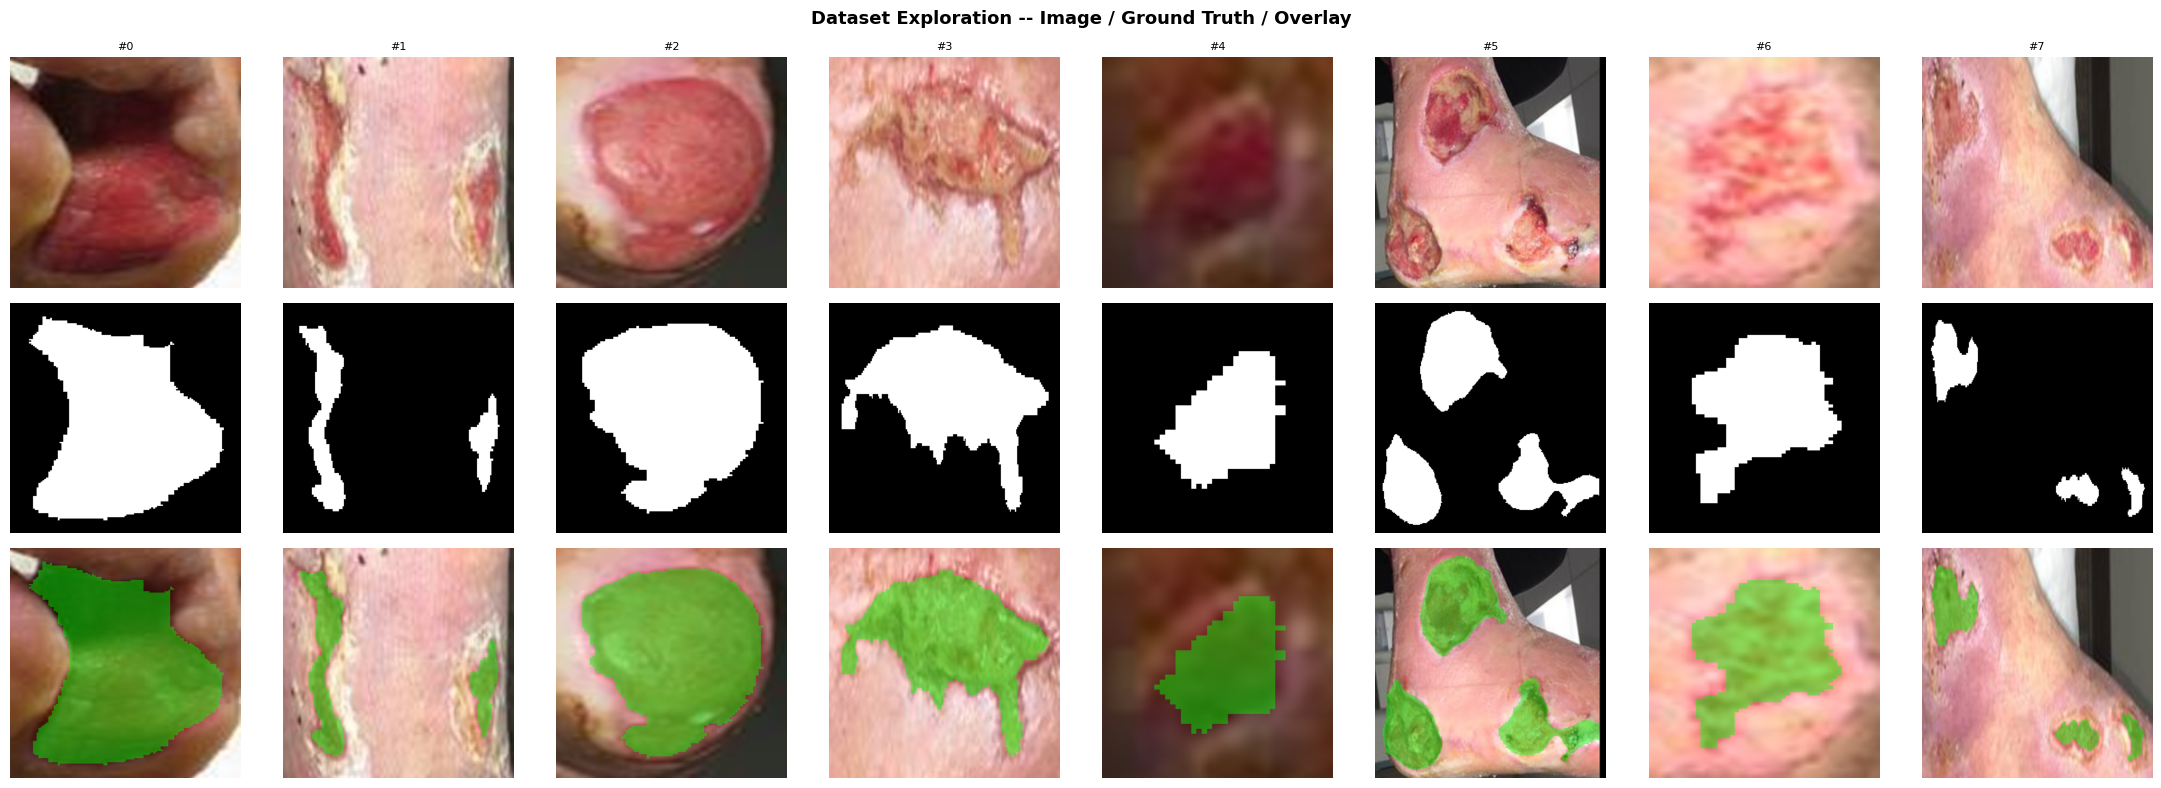

Saved data_exploration_m2.png


In [4]:
def denorm(t):
    mean=torch.tensor([0.485,0.456,0.406]).view(3,1,1)
    std =torch.tensor([0.229,0.224,0.225]).view(3,1,1)
    return (t.cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()

def overlay_mask(img_np,mask_np,alpha=0.45):
    out=img_np.copy(); out[mask_np>0]=out[mask_np>0]*(1-alpha)+np.array([0,1,0])*alpha
    return out.clip(0,1)

sample_idx=[]
for i in range(len(full_noaug)):
    _,m=full_noaug[i]
    if m.sum()>0: sample_idx.append(i)
    if len(sample_idx)==8: break

fig,axes=plt.subplots(3,8,figsize=(22,8))
fig.suptitle("Dataset Exploration -- Image / Ground Truth / Overlay",fontsize=13,fontweight="bold")
for col,idx in enumerate(sample_idx):
    img_t,mask_t=full_noaug[idx]
    img_np=denorm(img_t); mask_np=mask_t[0].numpy()
    axes[0,col].imshow(img_np);         axes[0,col].set_title(f"#{idx}",fontsize=8)
    axes[1,col].imshow(mask_np,cmap="gray")
    axes[2,col].imshow(overlay_mask(img_np,mask_np))
    for r in range(3): axes[r,col].axis("off")
axes[0,0].set_ylabel("Image",fontsize=9,labelpad=6)
axes[1,0].set_ylabel("Ground Truth",fontsize=9,labelpad=6)
axes[2,0].set_ylabel("Overlay",fontsize=9,labelpad=6)
plt.tight_layout()
plt.savefig("data_exploration_m2.png",dpi=120,bbox_inches="tight"); plt.show()
print("Saved data_exploration_m2.png")


## 5. Model Architecture

In [5]:
# ============================================================
# 5A. Mamba SSM Bottleneck Block
# ============================================================
class SSMBlock(nn.Module):
    def __init__(self, dim, d_state=16, d_conv=4, expand=2):
        super().__init__()
        d_inner=int(expand*dim); self.d_inner=d_inner; self.d_state=d_state
        self.norm    =nn.LayerNorm(dim)
        self.in_proj =nn.Linear(dim,d_inner*2,bias=False)
        self.conv1d  =nn.Conv1d(d_inner,d_inner,kernel_size=d_conv,
                                padding=d_conv-1,groups=d_inner,bias=True)
        self.act     =nn.SiLU()
        self.x_proj  =nn.Linear(d_inner,d_state*2+1,bias=False)
        self.dt_proj =nn.Linear(1,d_inner,bias=True)
        self.out_proj=nn.Linear(d_inner,dim,bias=False)
        self.dropout =nn.Dropout(DROPOUT_RATE)
        a_log=(torch.log(torch.arange(1,d_state+1).float())
               .unsqueeze(0).expand(d_inner,-1).contiguous())
        self.A_log=nn.Parameter(a_log); self.D=nn.Parameter(torch.ones(d_inner))
        nn.init.normal_(self.dt_proj.weight,std=0.01); nn.init.zeros_(self.dt_proj.bias)

    def forward(self,x):
        res=x; x=self.norm(x); B,L,C=x.shape
        x_in,z=self.in_proj(x).chunk(2,dim=-1)
        x_in=self.conv1d(x_in.transpose(1,2))[...,:L].transpose(1,2)
        x_in=self.act(x_in)
        dt_raw,_,_=torch.split(self.x_proj(x_in),[1,self.d_state,self.d_state],dim=-1)
        dt=F.softplus(self.dt_proj(dt_raw.clamp(-4,4)))
        y=x_in*self.D+(x_in*torch.sigmoid(dt)).cumsum(dim=1)/max(L,1)
        return self.dropout(self.out_proj(y*torch.sigmoid(z)))+res


class MambaBottleneck(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.norm=nn.GroupNorm(32,in_channels)
        self.ssm =SSMBlock(in_channels)
        self.proj=nn.Conv2d(in_channels,in_channels,1)
    def forward(self,x):
        B,C,H,W=x.shape; sc=x
        x=self.norm(x)
        x=self.ssm(x.flatten(2).transpose(1,2)).transpose(1,2).reshape(B,C,H,W)
        return self.proj(x)+sc


# ============================================================
# 5B. ConvNeXt-B Encoder
# ============================================================
class ConvNeXtEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights=ConvNeXt_Base_Weights.IMAGENET1K_V1 if pretrained else None
        backbone=models.convnext_base(weights=weights)
        feats=backbone.features
        # ConvNeXt-B feature stages:
        # stage 0: stem (4x4 patch tokenisation) -> /4,  128ch
        # stage 1: layer block                   -> /4,  128ch
        # stage 2: downsampling                  -> /8,  256ch
        # stage 3: layer block                   -> /8,  256ch
        # stage 4: downsampling                  -> /16, 512ch
        # stage 5: layer block                   -> /16, 512ch
        # stage 6: downsampling                  -> /32,1024ch
        # stage 7: layer block                   -> /32,1024ch
        self.s0=nn.Sequential(feats[0],feats[1])  # /4  128ch
        self.s1=nn.Sequential(feats[2],feats[3])  # /8  256ch
        self.s2=nn.Sequential(feats[4],feats[5])  # /16 512ch
        self.s3=nn.Sequential(feats[6],feats[7])  # /32 1024ch

    def forward(self,x):
        f0=self.s0(x)   # [B,128,H/4, W/4]
        f1=self.s1(f0)  # [B,256,H/8, W/8]
        f2=self.s2(f1)  # [B,512,H/16,W/16]
        f3=self.s3(f2)  # [B,1024,H/32,W/32]
        return f0,f1,f2,f3


# ============================================================
# 5C. Graph Node Feature Extractors
# ============================================================
class IntensityNodeExtractor(nn.Module):
    """Pixel statistics per patch: mean, std, min, max per channel = 12 features."""
    def __init__(self, patch_size=PATCH_SIZE, num_patches=NUM_PATCHES, node_dim=NODE_DIM):
        super().__init__()
        self.ps=patch_size; self.np=num_patches
        self.proj=nn.Linear(12,node_dim)

    def forward(self,x):
        # x: [B,3,H,W]
        B,C,H,W=x.shape
        ph=pw=max(H//int(self.np**0.5),1)
        # unfold into patches
        patches=x.unfold(2,ph,ph).unfold(3,pw,pw)  # [B,C,nh,nw,ph,pw]
        nh,nw=patches.shape[2],patches.shape[3]
        patches=patches.contiguous().view(B,C,nh*nw,ph*pw)  # [B,C,N,ph*pw]
        mn =patches.mean(-1)   # [B,C,N]
        sd =patches.std(-1)    # [B,C,N]
        mn_all=mn.mean(1,keepdim=True); sd_all=sd.mean(1,keepdim=True)
        feat=torch.cat([mn.permute(0,2,1), sd.permute(0,2,1),
                        mn_all.expand_as(mn).permute(0,2,1),
                        sd_all.expand_as(sd).permute(0,2,1)],dim=-1)  # [B,N,12]
        N_actual=feat.shape[1]
        if N_actual>=self.np:
            idx=torch.linspace(0,N_actual-1,self.np).long()
            feat=feat[:,idx,:]
        else:
            rep=math.ceil(self.np/N_actual)
            feat=feat.repeat(1,rep,1)[:,:self.np,:]
        return self.proj(feat)  # [B,NUM_PATCHES,node_dim]


class TextureNodeExtractor(nn.Module):
    """LBP-inspired texture features from encoder stage features."""
    def __init__(self, in_channels=128, num_patches=NUM_PATCHES, node_dim=NODE_DIM):
        super().__init__()
        self.num_patches=num_patches
        # Gabor-style depthwise conv filters (4 orientations)
        self.gabor=nn.Conv2d(in_channels,in_channels,kernel_size=3,padding=1,
                             groups=in_channels,bias=False)
        self.proj=nn.Linear(in_channels,node_dim)

    def forward(self,feat_map):
        # feat_map: [B,C,H,W] from encoder stage 0
        B,C,H,W=feat_map.shape
        tx=self.gabor(feat_map)                        # [B,C,H,W]
        tx=tx.flatten(2).transpose(1,2)                # [B,H*W,C]
        N=H*W
        if N>=self.num_patches:
            idx=torch.linspace(0,N-1,self.num_patches).long().to(feat_map.device)
            nodes=tx[:,idx,:]
        else:
            rep=math.ceil(self.num_patches/N)
            nodes=tx.repeat(1,rep,1)[:,:self.num_patches,:]
        return self.proj(nodes)  # [B,NUM_PATCHES,node_dim]


class PositionNodeExtractor(nn.Module):
    """Spatial coordinate encoding as positional node features."""
    def __init__(self, num_patches=NUM_PATCHES, node_dim=NODE_DIM):
        super().__init__()
        self.num_patches=num_patches
        self.pos_emb=nn.Embedding(num_patches,node_dim)
        self.coord_proj=nn.Linear(2,node_dim)

    def forward(self,device):
        # build normalised (x,y) grid coordinates
        n=int(self.num_patches**0.5)
        ys=torch.linspace(0,1,n,device=device)
        xs=torch.linspace(0,1,n,device=device)
        grid_y,grid_x=torch.meshgrid(ys,xs,indexing="ij")
        coords=torch.stack([grid_x.flatten(),grid_y.flatten()],dim=-1)  # [N,2]
        if coords.shape[0]<self.num_patches:
            idx=torch.linspace(0,coords.shape[0]-1,self.num_patches).long().to(device)
            coords=coords[idx]
        pos_feat=self.coord_proj(coords)                             # [N,node_dim]
        pos_emb =self.pos_emb(torch.arange(self.num_patches,device=device))
        return (pos_feat+pos_emb).unsqueeze(0)  # [1,NUM_PATCHES,node_dim]


# ============================================================
# 5D. Dynamic Hypergraph Builder
# ============================================================
def build_dynamic_hyperedges(nodes, threshold=HE_THRESHOLD):
    """
    Build incidence matrix H in {0,1}^{N x E} where E=N (each node seeds one hyperedge).
    Hyperedge e_i = {j : cosine_sim(node_i, node_j) > threshold}.
    Updated every forward pass (dynamic).
    nodes: [B,N,D]  -> returns H averaged over batch: [N,N]
    """
    nf  =F.normalize(nodes.detach().mean(0),dim=-1)  # [N,D]
    sim =nf@nf.T                                      # [N,N]
    H   =(sim>threshold).float()
    # ensure self-connections (diagonal)
    H   =H+torch.eye(H.shape[0],device=H.device).clamp(max=1.)
    return H  # [N,N]  incidence matrix


# ============================================================
# 5E. Hypergraph Neural Network (spectral convolution)
# ============================================================
class HGNNLayer(nn.Module):
    """
    Spectral HGNN layer:
      X_out = D_v^{-1} H W D_e^{-1} H^T X W_theta
    where D_v = degree of nodes, D_e = degree of hyperedges, W = hyperedge weights (all 1).
    """
    def __init__(self, node_dim=NODE_DIM, dropout=DROPOUT_RATE):
        super().__init__()
        self.W    =nn.Linear(node_dim,node_dim,bias=False)
        self.norm =nn.LayerNorm(node_dim)
        self.ffn  =nn.Sequential(nn.Linear(node_dim,node_dim*2),nn.GELU(),
                                  nn.Dropout(dropout),nn.Linear(node_dim*2,node_dim))
        self.norm2=nn.LayerNorm(node_dim)
        self.drop =nn.Dropout(dropout)

    def forward(self,X,H):
        # X:[B,N,D]  H:[N,N]
        Dv=H.sum(-1).clamp(min=1.)   # [N]   node degree
        De=H.sum(0).clamp(min=1.)    # [N]   hyperedge degree
        Dv_inv=1./Dv; De_inv=1./De
        # spectral conv: theta(X) -> H -> De_inv -> H^T -> Dv_inv
        Xw=self.W(X)                                             # [B,N,D]
        agg=Dv_inv.unsqueeze(-1)*(H@(De_inv.unsqueeze(-1)*(H.T@Xw.mean(0))))  # [N,D]
        agg=agg.unsqueeze(0).expand_as(X)
        X  =self.norm(X+self.drop(agg))
        X  =self.norm2(X+self.drop(self.ffn(X)))
        return X


class HGNN(nn.Module):
    def __init__(self, node_dim=NODE_DIM, num_layers=3):
        super().__init__()
        self.layers=nn.ModuleList([HGNNLayer(node_dim) for _ in range(num_layers)])

    def forward(self,X,H):
        for l in self.layers: X=l(X,H)
        return X


# ============================================================
# 5F. FPN Decoder
# ============================================================
class FPNDecoder(nn.Module):
    """
    Feature Pyramid Network decoder.
    Takes 4 encoder feature maps + graph context and produces a segmentation mask.
    """
    def __init__(self, in_channels=(128,256,512,1024), fpn_ch=256, graph_ch=NODE_DIM):
        super().__init__()
        # lateral 1x1 convs to project all stages to fpn_ch
        self.lat=nn.ModuleList([nn.Conv2d(c,fpn_ch,1) for c in in_channels])
        # output 3x3 convs
        self.out_conv=nn.ModuleList([
            nn.Sequential(nn.Conv2d(fpn_ch,fpn_ch,3,padding=1),
                          nn.BatchNorm2d(fpn_ch),nn.ReLU(inplace=True))
            for _ in in_channels])
        # graph context projection -> spatial
        self.graph_proj=nn.Linear(graph_ch,fpn_ch)
        # final head: upsample to full res and predict
        self.head=nn.Sequential(
            nn.Conv2d(fpn_ch,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.Conv2d(128,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(True),
            nn.Conv2d(64,1,1),
        )

    def forward(self,feats,graph_nodes,img_size):
        # feats: list [f0,f1,f2,f3]  (low->high stride)
        # graph_nodes: [B,N,D]
        # lateral projections
        lats=[l(f) for l,f in zip(self.lat,feats)]
        # top-down pathway
        for i in range(len(lats)-1,0,-1):
            lats[i-1]=lats[i-1]+F.interpolate(lats[i],size=lats[i-1].shape[2:],
                                               mode="bilinear",align_corners=False)
        outs=[conv(l) for conv,l in zip(self.out_conv,lats)]
        # inject graph context into finest scale (outs[0])
        B,_,H,W=outs[0].shape
        gc=self.graph_proj(graph_nodes).mean(1)    # [B,fpn_ch]
        gc=gc[:,:,None,None].expand(B,-1,H,W)
        outs[0]=outs[0]+gc
        # upsample finest map to full resolution
        x=F.interpolate(outs[0],size=img_size,mode="bilinear",align_corners=False)
        return self.head(x)   # [B,1,H,W]


# ============================================================
# 5G. Full Model
# ============================================================
class WoundSegModel2(nn.Module):
    def __init__(self, num_patches=NUM_PATCHES, node_dim=NODE_DIM, pretrained=True):
        super().__init__()
        self.encoder      =ConvNeXtEncoder(pretrained)
        self.bottleneck   =MambaBottleneck(1024)
        # node extractors
        self.int_nodes    =IntensityNodeExtractor(PATCH_SIZE,num_patches,node_dim)
        self.tex_nodes    =TextureNodeExtractor(128,num_patches,node_dim)
        self.pos_nodes    =PositionNodeExtractor(num_patches,node_dim)
        # combine 3 node types
        self.node_fuse    =nn.Sequential(nn.Linear(node_dim*3,node_dim),nn.ReLU(True))
        # HGNN
        self.hgnn         =HGNN(node_dim,num_layers=3)
        # decoder
        self.decoder      =FPNDecoder((128,256,512,1024),256,node_dim)
        self.num_patches  =num_patches

    def forward(self,x):
        B=x.shape[0]; img_h,img_w=x.shape[2],x.shape[3]
        # 1. Encode
        f0,f1,f2,f3=self.encoder(x)
        # 2. Mamba bottleneck
        f3=self.bottleneck(f3)
        # 3. Node features
        int_n=self.int_nodes(x)                   # [B,N,D]
        tex_n=self.tex_nodes(f0)                  # [B,N,D]
        pos_n=self.pos_nodes(x.device).expand(B,-1,-1)  # [B,N,D]
        nodes=self.node_fuse(torch.cat([int_n,tex_n,pos_n],dim=-1))  # [B,N,D]
        # 4. Dynamic hypergraph
        H=build_dynamic_hyperedges(nodes)         # [N,N]
        # 5. HGNN
        nodes=self.hgnn(nodes,H)                  # [B,N,D]
        # 6. FPN decode
        logits=self.decoder([f0,f1,f2,f3],nodes,(img_h,img_w))
        return logits   # [B,1,H,W]


model=WoundSegModel2(pretrained=True).to(DEVICE)
n_params=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters : {n_params/1e6:.2f} M")
with torch.no_grad():
    _d=torch.randn(2,3,IMG_SIZE,IMG_SIZE).to(DEVICE)
    _o=model(_d)
    print(f"Output shape         : {tuple(_o.shape)}  (expected [2, 1, {IMG_SIZE}, {IMG_SIZE}])")
    del _d,_o
torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/convnext_base-6075fbad.pth" to /root/.cache/torch/hub/checkpoints/convnext_base-6075fbad.pth


100%|██████████| 338M/338M [00:03<00:00, 92.6MB/s]


Trainable parameters : 99.57 M
Output shape         : (2, 1, 512, 512)  (expected [2, 1, 512, 512])


## 6. Loss Function and Metrics

In [6]:
class FocalDiceLoss(nn.Module):
    """Focal loss + Dice loss for class-imbalanced wound segmentation."""
    def __init__(self, focal_w=0.4, dice_w=0.6, gamma=2.0, alpha=0.25, smooth=1.0):
        super().__init__()
        self.focal_w=focal_w; self.dice_w=dice_w
        self.gamma=gamma; self.alpha=alpha; self.smooth=smooth

    def forward(self,logits,targets):
        if not torch.isfinite(logits).all():
            logits=torch.nan_to_num(logits,nan=0.,posinf=20.,neginf=-20.)
        # Focal loss
        bce  =F.binary_cross_entropy_with_logits(logits,targets,reduction="none")
        pt   =torch.exp(-bce)
        focal=self.alpha*(1-pt)**self.gamma*bce
        focal=focal.mean()
        # Dice loss
        p    =torch.sigmoid(logits)
        inter=(p*targets).sum((1,2,3))
        union=p.sum((1,2,3))+targets.sum((1,2,3))
        dice =(1-(2*inter+self.smooth)/(union+self.smooth)).mean()
        return self.focal_w*focal+self.dice_w*dice


def hausdorff_distance_95(pred_np,gt_np):
    from scipy.spatial.distance import cdist as _cdist
    pb=pred_np.astype(bool); gb=gt_np.astype(bool)
    if not pb.any() and not gb.any(): return 0.0
    if not pb.any() or  not gb.any(): return np.nan
    pb2=pb^binary_erosion(pb); gb2=gb^binary_erosion(gb)
    py,px=np.where(pb2); gy,gx=np.where(gb2)
    pp=np.stack([py,px],1).astype(np.float32); gp=np.stack([gy,gx],1).astype(np.float32)
    d1=_cdist(pp,gp).min(1); d2=_cdist(gp,pp).min(1)
    return float(np.percentile(np.concatenate([d1,d2]),95))


@torch.no_grad()
def compute_metrics(logits,masks,threshold=0.5):
    p=(torch.sigmoid(logits)>threshold).float(); m=masks
    tp=(p*m).sum((1,2,3)); fp=(p*(1-m)).sum((1,2,3)); fn=((1-p)*m).sum((1,2,3))
    dice=(2*tp+1)/(2*tp+fp+fn+1); iou=(tp+1)/(tp+fp+fn+1)
    prec=(tp+1)/(tp+fp+1);        rec=(tp+1)/(tp+fn+1)
    hd_vals=[]
    pn=p.cpu().numpy().astype(np.uint8); mn=m.cpu().numpy().astype(np.uint8)
    for i in range(pn.shape[0]):
        hd=hausdorff_distance_95(pn[i,0],mn[i,0])
        if not np.isnan(hd): hd_vals.append(hd)
    hd95=float(np.mean(hd_vals)) if hd_vals else 0.0
    return {"dice":dice.mean().item(),"iou":iou.mean().item(),
            "precision":prec.mean().item(),"recall":rec.mean().item(),"hd95":hd95}

criterion=FocalDiceLoss()
print("Focal+Dice loss and metrics ready.")


Focal+Dice loss and metrics ready.


## 7. EMA, TTA and Training Utilities

In [7]:
class EMA:
    def __init__(self,model,decay=EMA_DECAY):
        self.decay=decay; self._backup={}
        self.shadow={k:v.clone().detach() for k,v in model.state_dict().items()}
    def update(self,model):
        for k,v in model.state_dict().items():
            self.shadow[k]=self.decay*self.shadow[k]+(1-self.decay)*v.detach()
    def apply(self,model):
        self._backup={k:v.clone() for k,v in model.state_dict().items()}
        model.load_state_dict(self.shadow)
    def restore(self,model):
        if self._backup: model.load_state_dict(self._backup)


def tta_predict(model,img_t,n_aug=6):
    augs   =[lambda x:x, lambda x:torch.flip(x,[-1]), lambda x:torch.flip(x,[-2]),
             lambda x:torch.rot90(x, 1,[-2,-1]), lambda x:torch.rot90(x, 2,[-2,-1]),
             lambda x:torch.rot90(x, 3,[-2,-1])]
    de_augs=[lambda x:x, lambda x:torch.flip(x,[-1]), lambda x:torch.flip(x,[-2]),
             lambda x:torch.rot90(x,-1,[-2,-1]), lambda x:torch.rot90(x,-2,[-2,-1]),
             lambda x:torch.rot90(x,-3,[-2,-1])]
    model.eval(); preds=[]
    with torch.no_grad():
        for a,d in zip(augs[:n_aug],de_augs[:n_aug]):
            preds.append(d(torch.sigmoid(model(a(img_t)))))
    return torch.stack(preds).mean(0)


def train_one_epoch(model,loader,optimizer,criterion,ema):
    model.train(); total=0.; clips=0
    for imgs,masks in loader:
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        optimizer.zero_grad()
        loss=criterion(model(imgs),masks)
        if not torch.isfinite(loss): print("  [warn] non-finite loss skipped"); continue
        loss.backward()
        gn=torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        if gn>1.: clips+=1
        optimizer.step(); ema.update(model); total+=loss.item()
    return total/max(len(loader),1), clips


@torch.no_grad()
def evaluate(model,loader,criterion):
    model.eval(); tloss=0.
    acc={"dice":0.,"iou":0.,"precision":0.,"recall":0.,"hd95":0.}
    for imgs,masks in loader:
        imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
        logits=model(imgs); loss=criterion(logits,masks)
        if torch.isfinite(loss): tloss+=loss.item()
        m=compute_metrics(logits,masks)
        for k in acc: acc[k]+=m[k]
    n=max(len(loader),1)
    return tloss/n,{k:v/n for k,v in acc.items()}


def get_scheduler(optimizer,warmup_ep,total_ep):
    def lr_lambda(ep):
        if ep<warmup_ep: return (ep+1)/warmup_ep
        p=(ep-warmup_ep)/max(total_ep-warmup_ep,1)
        return 0.5*(1+math.cos(math.pi*p))
    return torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda)


optimizer=torch.optim.AdamW(model.parameters(),lr=LR,weight_decay=1e-4)
scheduler=get_scheduler(optimizer,WARMUP_EPOCHS,NUM_EPOCHS)
ema=EMA(model)
print("Optimiser, scheduler, EMA ready.")


Optimiser, scheduler, EMA ready.


## 8. Training Loop

In [8]:
history={
    "train_loss":[],"train_dice":[],"train_iou":[],
    "val_loss":  [],"val_dice":  [],"val_iou":  [],
    "val_hd95":  [],"lr":        [],
}
best_score=0.; best_dice=0.; best_iou=0.; no_improve=0; stop_epoch=NUM_EPOCHS

for epoch in range(1,NUM_EPOCHS+1):
    torch.cuda.empty_cache()
    tr_loss,clips=train_one_epoch(model,train_loader,optimizer,criterion,ema)
    va_loss,va_met=evaluate(model,val_loader,criterion)
    current_lr=optimizer.param_groups[0]["lr"]
    scheduler.step()

    model.eval()
    tr_d=tr_i=0.; nb=0
    with torch.no_grad():
        for imgs,masks in train_loader:
            imgs,masks=imgs.to(DEVICE),masks.to(DEVICE)
            m=compute_metrics(model(imgs),masks)
            tr_d+=m["dice"]; tr_i+=m["iou"]; nb+=1
            if nb>=20: break
    tr_dice=tr_d/max(nb,1); tr_iou=tr_i/max(nb,1)
    model.train()

    history["train_loss"].append(tr_loss); history["train_dice"].append(tr_dice)
    history["train_iou"].append(tr_iou);   history["val_loss"].append(va_loss)
    history["val_dice"].append(va_met["dice"]); history["val_iou"].append(va_met["iou"])
    history["val_hd95"].append(va_met["hd95"]); history["lr"].append(current_lr)

    combined=0.5*va_met["dice"]+0.5*va_met["iou"]; marker=""
    if combined>best_score:
        best_score=combined; best_dice=va_met["dice"]; best_iou=va_met["iou"]
        torch.save(model.state_dict(),"best_model_model2.pth"); no_improve=0; marker="  [saved]"
    else: no_improve+=1

    torch.save({"epoch":epoch,"model":model.state_dict(),"optimizer":optimizer.state_dict(),
                "scheduler":scheduler.state_dict(),"ema_shadow":ema.shadow,
                "best_score":best_score,"history":history},"last_checkpoint_model2.pth")

    print(f"Epoch {epoch:3d}/{NUM_EPOCHS} | lr={current_lr:.2e} | "
          f"train_loss={tr_loss:.4f}  train_dice={tr_dice:.4f} | "
          f"val_loss={va_loss:.4f}  val_dice={va_met['dice']:.4f}  "
          f"val_iou={va_met['iou']:.4f}  val_hd95={va_met['hd95']:.2f} | "
          f"combined={combined:.4f}  patience={no_improve}/{PATIENCE}{marker}")

    if no_improve>=PATIENCE:
        stop_epoch=epoch
        print(f"\nEarly stopping at epoch {epoch}.")
        break

print(f"\nBest Val  Dice={best_dice:.4f}  IoU={best_iou:.4f}  Combined={best_score:.4f}")
print(f"Training stopped at epoch {stop_epoch}/{NUM_EPOCHS}")


Epoch   1/50 | lr=2.00e-05 | train_loss=0.3239  train_dice=0.6212 | val_loss=0.2844  val_dice=0.6209  val_iou=0.5530  val_hd95=35.44 | combined=0.5870  patience=0/10  [saved]
Epoch   2/50 | lr=4.00e-05 | train_loss=0.2899  train_dice=0.6250 | val_loss=0.2640  val_dice=0.6477  val_iou=0.5917  val_hd95=29.84 | combined=0.6197  patience=0/10  [saved]
Epoch   3/50 | lr=6.00e-05 | train_loss=0.2753  train_dice=0.6606 | val_loss=0.2409  val_dice=0.6497  val_iou=0.5936  val_hd95=28.32 | combined=0.6217  patience=0/10  [saved]
Epoch   4/50 | lr=8.00e-05 | train_loss=0.2598  train_dice=0.6201 | val_loss=0.2653  val_dice=0.6352  val_iou=0.5715  val_hd95=32.29 | combined=0.6034  patience=1/10
Epoch   5/50 | lr=1.00e-04 | train_loss=0.2523  train_dice=0.9314 | val_loss=0.2322  val_dice=0.9204  val_iou=0.8658  val_hd95=28.25 | combined=0.8931  patience=0/10  [saved]
Epoch   6/50 | lr=1.00e-04 | train_loss=0.2415  train_dice=0.9444 | val_loss=0.2288  val_dice=0.9279  val_iou=0.8775  val_hd95=25.83 |

## 9. Training Curves

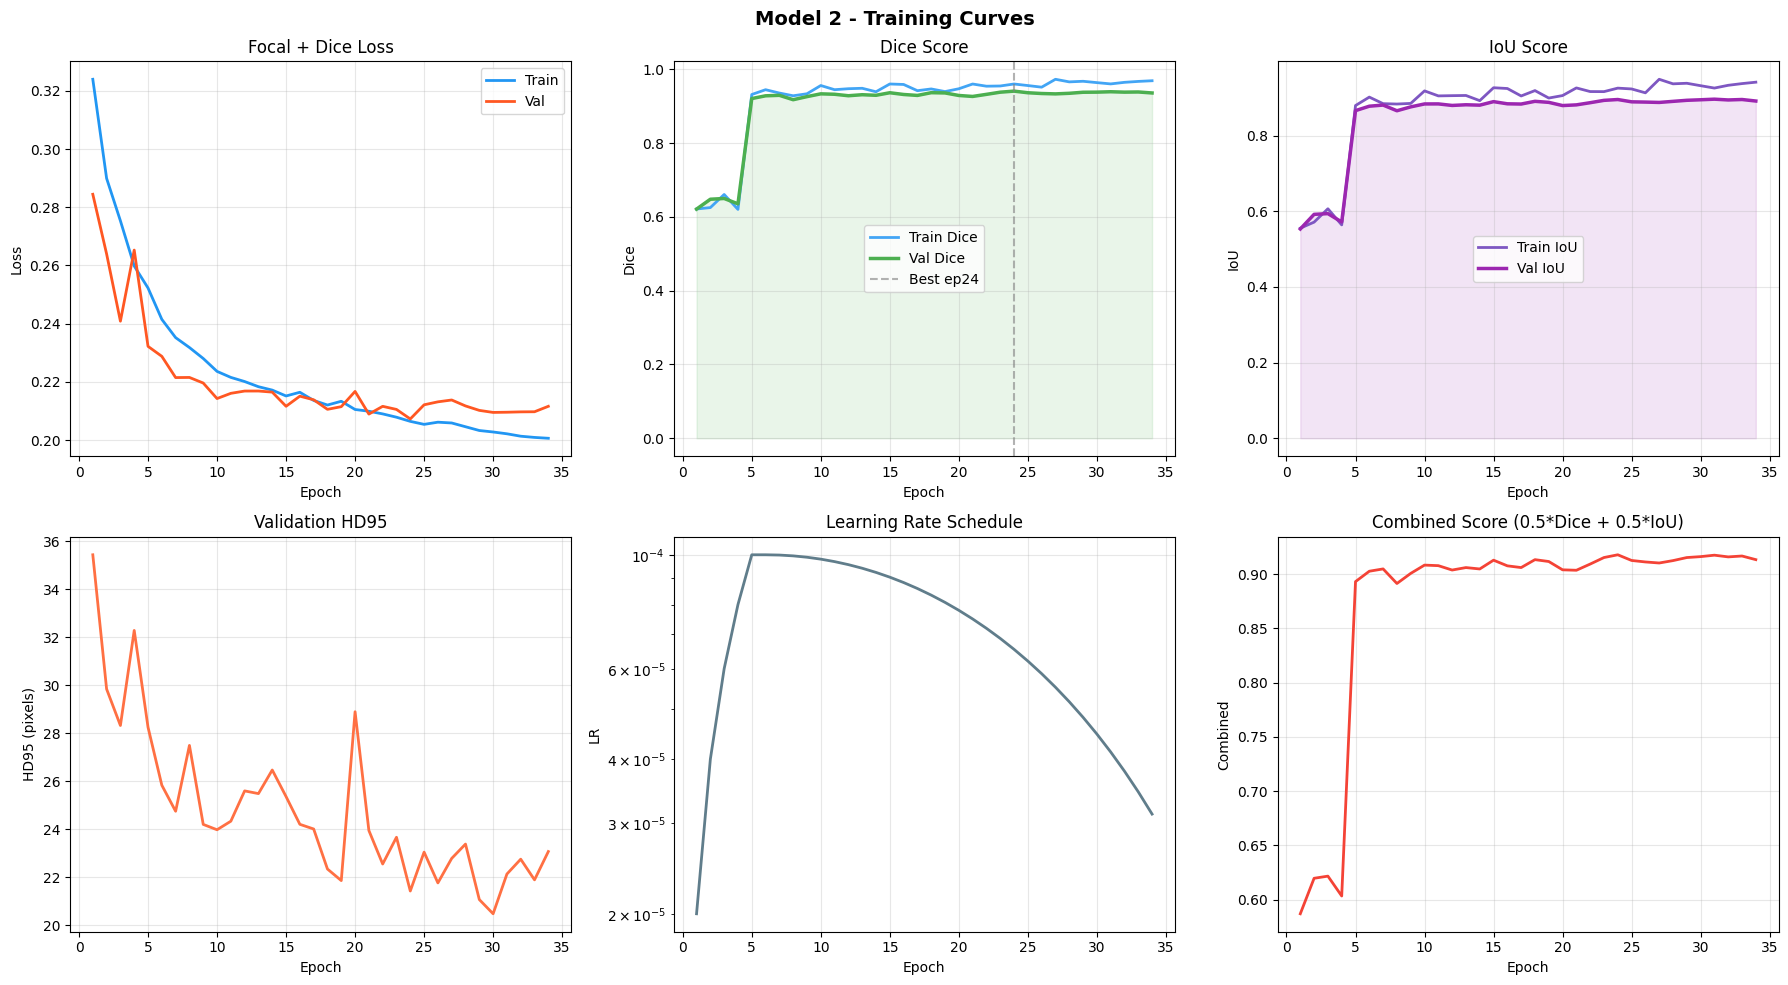

Saved training_curves_m2.png


In [9]:
ep=range(1,len(history["train_loss"])+1)
fig,axes=plt.subplots(2,3,figsize=(18,10))
fig.suptitle("Model 2 - Training Curves",fontsize=14,fontweight="bold")

axes[0,0].plot(ep,history["train_loss"],label="Train",color="#2196F3",linewidth=2)
axes[0,0].plot(ep,history["val_loss"],  label="Val",  color="#FF5722",linewidth=2)
axes[0,0].set_title("Focal + Dice Loss"); axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Loss"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep,history["train_dice"],label="Train Dice",color="#42A5F5",linewidth=2)
axes[0,1].plot(ep,history["val_dice"],  label="Val Dice",  color="#4CAF50",linewidth=2.5)
axes[0,1].fill_between(ep,history["val_dice"],alpha=0.12,color="#4CAF50")
best_e=int(np.argmax(history["val_dice"]))
axes[0,1].axvline(best_e+1,color="gray",linestyle="--",alpha=0.6,label=f"Best ep{best_e+1}")
axes[0,1].set_title("Dice Score"); axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Dice"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(ep,history["train_iou"],label="Train IoU",color="#7E57C2",linewidth=2)
axes[0,2].plot(ep,history["val_iou"],  label="Val IoU",  color="#9C27B0",linewidth=2.5)
axes[0,2].fill_between(ep,history["val_iou"],alpha=0.12,color="#9C27B0")
axes[0,2].set_title("IoU Score"); axes[0,2].set_xlabel("Epoch")
axes[0,2].set_ylabel("IoU"); axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(ep,history["val_hd95"],color="#FF7043",linewidth=2)
axes[1,0].set_title("Validation HD95"); axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("HD95 (pixels)"); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep,history["lr"],color="#607D8B",linewidth=2)
axes[1,1].set_title("Learning Rate Schedule"); axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("LR"); axes[1,1].set_yscale("log"); axes[1,1].grid(alpha=0.3)

comb=[0.5*d+0.5*i for d,i in zip(history["val_dice"],history["val_iou"])]
axes[1,2].plot(ep,comb,color="#F44336",linewidth=2)
axes[1,2].set_title("Combined Score (0.5*Dice + 0.5*IoU)")
axes[1,2].set_xlabel("Epoch"); axes[1,2].set_ylabel("Combined"); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_m2.png",dpi=120,bbox_inches="tight"); plt.show()
print("Saved training_curves_m2.png")


## 10. Test Set Evaluation (EMA + 6-fold TTA)

In [10]:
model.load_state_dict(torch.load("best_model_model2.pth",map_location=DEVICE))
ema.apply(model)

test_metrics={"dice":[],"iou":[],"precision":[],"recall":[],"hd95":[]}
os.makedirs("test_predictions_m2",exist_ok=True)
all_imgs=[]; all_masks=[]; all_preds=[]

model.eval()
for i,(imgs,masks) in enumerate(test_loader):
    imgs=imgs.to(DEVICE)
    preds=tta_predict(model,imgs,n_aug=6)
    preds_bin=(preds>0.5).float()
    cv2.imwrite(f"test_predictions_m2/pred_{i:04d}.png",
                (preds_bin[0,0].cpu().numpy()*255).astype(np.uint8))
    if masks.sum()>0:
        masks_d=masks.to(DEVICE)
        logits_a=torch.log(preds.clamp(1e-6,1-1e-6)/(1-preds.clamp(1e-6,1-1e-6)))
        m=compute_metrics(logits_a,masks_d)
        for k in test_metrics: test_metrics[k].append(m[k])
    if masks.sum()>0 and len(all_imgs)<12:
        all_imgs.append(imgs[0].cpu()); all_masks.append(masks[0]); all_preds.append(preds_bin[0].cpu())

n_eval=len(test_metrics["dice"])
print("-"*62)
print("  Test Set Results  (EMA + 6-fold TTA)")
print("-"*62)
print(f"  {'Metric':<14} {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-"*62)
for k,v in test_metrics.items():
    arr=np.array(v)
    print(f"  {k.capitalize():<14} {arr.mean():>8.4f}  {arr.std():>8.4f}  "
          f"{arr.min():>8.4f}  {arr.max():>8.4f}")
print("-"*62)
print(f"  Evaluated on {n_eval} labelled test samples")
print("-"*62)
ema.restore(model)


--------------------------------------------------------------
  Test Set Results  (EMA + 6-fold TTA)
--------------------------------------------------------------
  Metric             Mean       Std       Min       Max
--------------------------------------------------------------
  Dice             0.9367    0.0461    0.7612    0.9894
  Iou              0.8843    0.0763    0.6145    0.9789
  Precision        0.9341    0.0672    0.6710    1.0000
  Recall           0.9451    0.0609    0.6166    0.9987
  Hd95            23.4275   28.7948    4.1231  268.4287
--------------------------------------------------------------
  Evaluated on 168 labelled test samples
--------------------------------------------------------------


## 11. Metric Summary Chart

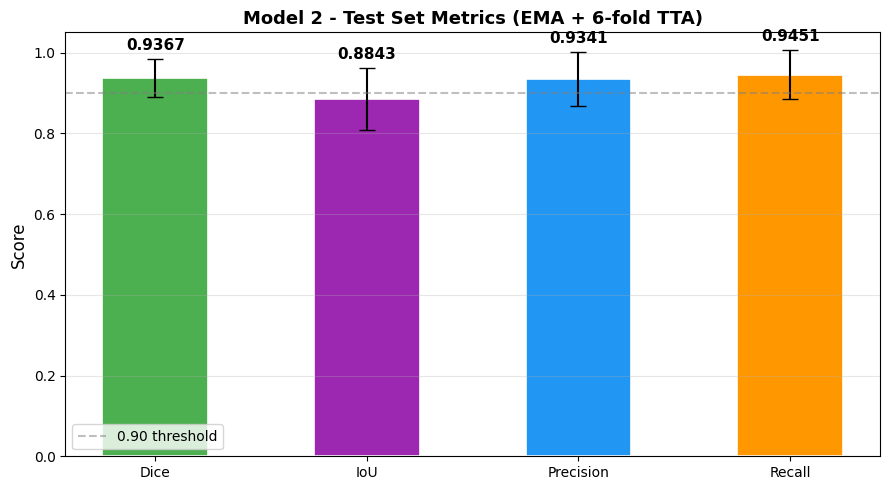

Saved metric_summary_m2.png


In [11]:
names=["Dice","IoU","Precision","Recall"]
keys =["dice","iou","precision","recall"]
means=[np.mean(test_metrics[k]) for k in keys]
stds =[np.std(test_metrics[k])  for k in keys]
cols =["#4CAF50","#9C27B0","#2196F3","#FF9800"]

fig,ax=plt.subplots(figsize=(9,5))
bars=ax.bar(names,means,yerr=stds,capsize=6,color=cols,edgecolor="white",linewidth=1.2,width=0.5)
ax.set_ylim(0,1.05); ax.set_ylabel("Score",fontsize=12)
ax.set_title("Model 2 - Test Set Metrics (EMA + 6-fold TTA)",fontsize=13,fontweight="bold")
ax.axhline(0.9,color="gray",linestyle="--",alpha=0.5,label="0.90 threshold")
for bar,mn,sd in zip(bars,means,stds):
    ax.text(bar.get_x()+bar.get_width()/2.,mn+sd+0.015,f"{mn:.4f}",
            ha="center",va="bottom",fontsize=11,fontweight="bold")
ax.legend(); ax.grid(axis="y",alpha=0.3)
plt.tight_layout()
plt.savefig("metric_summary_m2.png",dpi=120,bbox_inches="tight"); plt.show()
print("Saved metric_summary_m2.png")


## 12. Prediction Grid -- Image / Ground Truth / Prediction / Difference

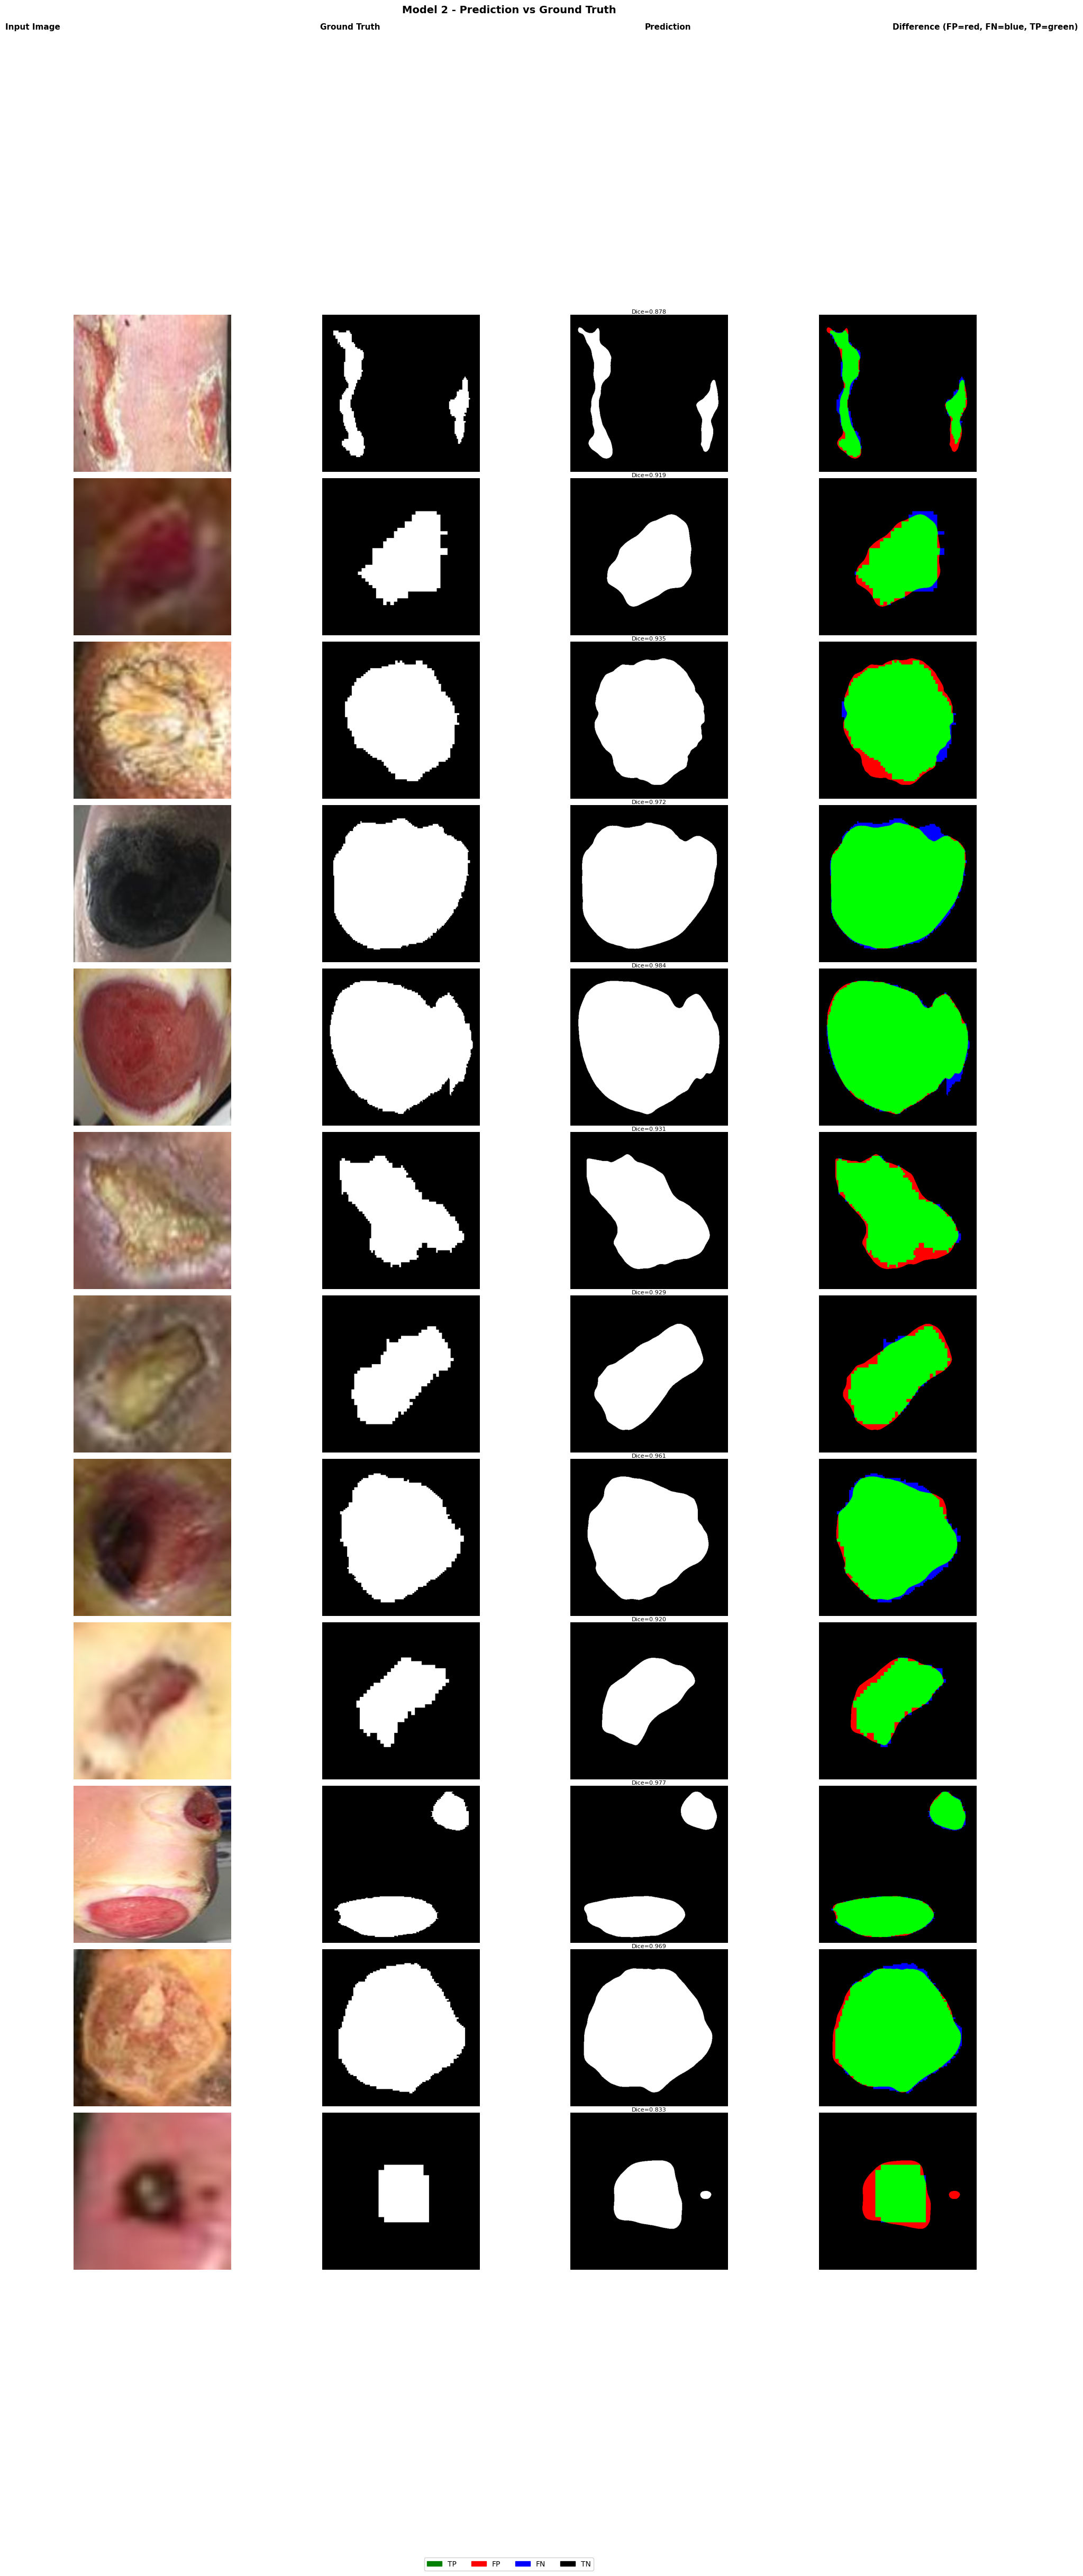

Saved prediction_grid_m2.png


In [12]:
n_show=min(len(all_imgs),12)
fig=plt.figure(figsize=(24,n_show*4))
gs=GridSpec(n_show,4,figure=fig,hspace=0.04,wspace=0.04)
for c,t in enumerate(["Input Image","Ground Truth","Prediction",
                       "Difference (FP=red, FN=blue, TP=green)"]):
    fig.text((c+0.5)/4.,0.995,t,ha="center",va="top",fontsize=11,fontweight="bold")

for row in range(n_show):
    img_np=denorm(all_imgs[row]); gt_np=all_masks[row][0].numpy(); pred_np=all_preds[row][0].numpy()
    diff=np.zeros((*gt_np.shape,3))
    diff[(pred_np==1)&(gt_np==0)]=[1,0,0]
    diff[(pred_np==0)&(gt_np==1)]=[0,0,1]
    diff[(pred_np==1)&(gt_np==1)]=[0,1,0]
    for col,(data,cmap,vr) in enumerate([(img_np,None,None),(gt_np,"gray",(0,1)),
                                          (pred_np,"gray",(0,1)),(diff,None,None)]):
        ax=fig.add_subplot(gs[row,col])
        kw=dict(cmap=cmap) if cmap else {}
        if vr: kw.update(vmin=vr[0],vmax=vr[1])
        ax.imshow(data,**kw); ax.axis("off")
        if col==2:
            pt=torch.tensor(pred_np).unsqueeze(0).unsqueeze(0)
            gt=torch.tensor(gt_np).unsqueeze(0).unsqueeze(0)
            d=(2*(pt*gt).sum()+1)/(pt.sum()+gt.sum()+1)
            ax.set_title(f"Dice={d:.3f}",fontsize=8,pad=2)

patches=[mpatches.Patch(color="green",label="TP"),mpatches.Patch(color="red",label="FP"),
         mpatches.Patch(color="blue",label="FN"),mpatches.Patch(color="black",label="TN")]
fig.legend(handles=patches,loc="lower center",ncol=4,fontsize=10,
           bbox_to_anchor=(0.5,-0.01),framealpha=0.9)
plt.suptitle("Model 2 - Prediction vs Ground Truth",fontsize=14,fontweight="bold",y=1.002)
plt.savefig("prediction_grid_m2.png",dpi=110,bbox_inches="tight"); plt.show()
print("Saved prediction_grid_m2.png")


## 13. Per-Sample Score Distribution

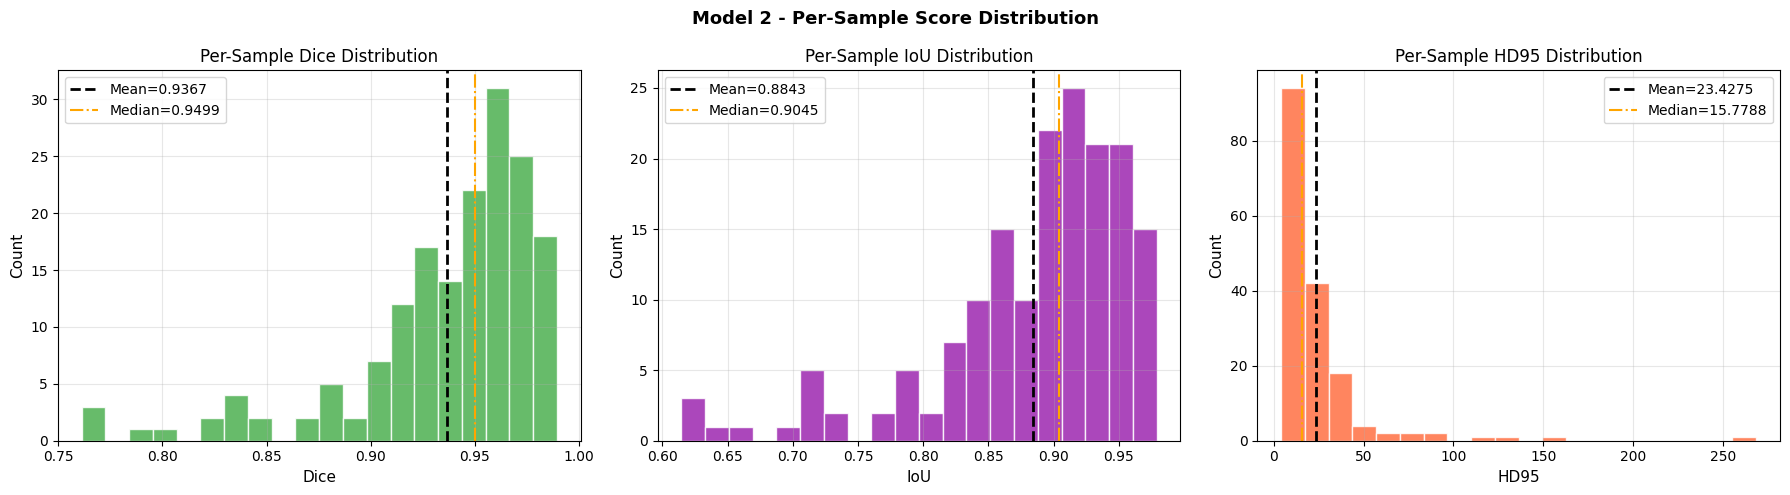

Saved score_distribution_m2.png


In [13]:
fig,axes=plt.subplots(1,3,figsize=(18,5))
fig.suptitle("Model 2 - Per-Sample Score Distribution",fontsize=13,fontweight="bold")
for ax,key,label,color in [(axes[0],"dice","Dice","#4CAF50"),
                            (axes[1],"iou", "IoU", "#9C27B0"),
                            (axes[2],"hd95","HD95","#FF7043")]:
    arr=np.array(test_metrics[key])
    ax.hist(arr,bins=20,color=color,edgecolor="white",alpha=0.85)
    ax.axvline(arr.mean(),    color="black", linestyle="--",linewidth=2,label=f"Mean={arr.mean():.4f}")
    ax.axvline(np.median(arr),color="orange",linestyle="-.",linewidth=1.5,label=f"Median={np.median(arr):.4f}")
    ax.set_xlabel(label,fontsize=11); ax.set_ylabel("Count",fontsize=11)
    ax.set_title(f"Per-Sample {label} Distribution"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("score_distribution_m2.png",dpi=120,bbox_inches="tight"); plt.show()
print("Saved score_distribution_m2.png")


## 14. Save Results Summary

In [14]:
summary={
    "architecture":"ConvNeXt-B + Mamba + Dynamic Hypergraph + FPN",
    "datasets":["Foot Ulcer Segmentation Challenge","Medetec_foot_ulcer_22"],
    "total_images":len(full_noaug),
    "split":{"train":len(train_sub.indices),"val":len(val_sub.indices),"test":len(test_sub.indices)},
    "hyperparameters":{"img_size":IMG_SIZE,"batch_size":BATCH_SIZE,"lr":LR,
                       "warmup_epochs":WARMUP_EPOCHS,"ema_decay":EMA_DECAY,
                       "patience":PATIENCE,"dropout":DROPOUT_RATE,
                       "he_threshold":HE_THRESHOLD,"loss":"0.4*Focal + 0.6*Dice"},
    "training":{"epochs_run":len(history["train_loss"]),"best_val_dice":float(best_dice),
                "best_val_iou":float(best_iou),"best_combined":float(best_score)},
    "test_metrics":{k:{"mean":float(np.mean(v)),"std":float(np.std(v)),
                        "min":float(np.min(v)),"max":float(np.max(v))}
                    for k,v in test_metrics.items() if v},
    "training_history":{k:[float(x) for x in v] for k,v in history.items()},
}
with open("model2_results.json","w") as f: json.dump(summary,f,indent=2)

print("-"*56)
print("  MODEL 2 -- FINAL SUMMARY")
print("-"*56)
print(f"  Architecture   : ConvNeXt-B + Mamba + Dynamic Hypergraph + FPN")
print(f"  Datasets       : FUSC + Medetec  ({len(full_noaug)} total images)")
print(f"  Train/Val/Test : {len(train_sub.indices)} / {len(val_sub.indices)} / {len(test_sub.indices)}")
print(f"  Epochs run     : {len(history['train_loss'])} / {NUM_EPOCHS}")
print(f"  Best Val Dice  : {best_dice:.4f}")
print(f"  Best Val IoU   : {best_iou:.4f}")
print(f"  Best Combined  : {best_score:.4f}")
if test_metrics["dice"]:
    print(f"  Test Dice      : {np.mean(test_metrics['dice']):.4f} +/- {np.std(test_metrics['dice']):.4f}")
    print(f"  Test IoU       : {np.mean(test_metrics['iou']):.4f} +/- {np.std(test_metrics['iou']):.4f}")
    print(f"  Test Precision : {np.mean(test_metrics['precision']):.4f}")
    print(f"  Test Recall    : {np.mean(test_metrics['recall']):.4f}")
    print(f"  Test HD95      : {np.mean(test_metrics['hd95']):.2f} px")
print("-"*56)
print("  Saved: best_model_model2.pth  last_checkpoint_model2.pth")
print("         model2_results.json    training_curves_m2.png")
print("         metric_summary_m2.png   prediction_grid_m2.png")
print("         score_distribution_m2.png  test_predictions_m2/")
print("-"*56)


--------------------------------------------------------
  MODEL 2 -- FINAL SUMMARY
--------------------------------------------------------
  Architecture   : ConvNeXt-B + Mamba + Dynamic Hypergraph + FPN
  Datasets       : FUSC + Medetec  (1370 total images)
  Train/Val/Test : 913 / 228 / 229
  Epochs run     : 34 / 50
  Best Val Dice  : 0.9406
  Best Val IoU   : 0.8951
  Best Combined  : 0.9178
  Test Dice      : 0.9367 +/- 0.0461
  Test IoU       : 0.8843 +/- 0.0763
  Test Precision : 0.9341
  Test Recall    : 0.9451
  Test HD95      : 23.43 px
--------------------------------------------------------
  Saved: best_model_model2.pth  last_checkpoint_model2.pth
         model2_results.json    training_curves_m2.png
         metric_summary_m2.png   prediction_grid_m2.png
         score_distribution_m2.png  test_predictions_m2/
--------------------------------------------------------


## 15. Test-Set Scoring Policy for Empty-Mask Images

The original loop only scores images where `masks.sum() > 0`, silently dropping wound-free images from the reported Dice/IoU. A reviewer will ask how these are handled. This cell re-scores the **full** test set, including empty-mask images (scored as Dice=1.0 / HD95=0.0 when both prediction and GT are empty, and penalised when the model hallucinates a wound), and reports both numbers side-by-side.


In [15]:
# Re-evaluate including empty-mask (wound-free) test images, scored explicitly.
model.load_state_dict(torch.load("best_model_model2.pth", map_location=DEVICE))
ema.apply(model)
model.eval()

full_test_metrics = {"dice": [], "iou": [], "precision": [], "recall": [], "hd95": []}
n_empty_gt = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs = imgs.to(DEVICE)
        preds = tta_predict(model, imgs, n_aug=6)
        masks_d = masks.to(DEVICE)

        if masks.sum() == 0:
            n_empty_gt += 1

        logits_approx = torch.log(
            preds.clamp(1e-6, 1.0 - 1e-6) / (1.0 - preds.clamp(1e-6, 1.0 - 1e-6))
        )
        m = compute_metrics(logits_approx, masks_d)
        for k in full_test_metrics:
            full_test_metrics[k].append(m[k])

ema.restore(model)

print(f"Lesion-only test images   : {len(test_metrics['dice'])}")
print(f"Wound-free (empty GT)     : {n_empty_gt}")
print(f"Full test set             : {len(full_test_metrics['dice'])}")
print()
print(f"{'Metric':<12} {'Lesion-only':>14} {'Full test set':>16}")
for k in full_test_metrics:
    lesion_mean = np.mean(test_metrics[k]) if test_metrics[k] else float("nan")
    full_mean   = np.mean(full_test_metrics[k])
    print(f"{k.capitalize():<12} {lesion_mean:>14.4f} {full_mean:>16.4f}")

with open("model2_full_test_metrics.json", "w") as f:
    json.dump({k: [float(x) for x in v] for k, v in full_test_metrics.items()}, f, indent=2)
print("\nSaved model2_full_test_metrics.json")


Lesion-only test images   : 168
Wound-free (empty GT)     : 61
Full test set             : 229

Metric          Lesion-only    Full test set
Dice                 0.9367           0.9536
Iou                  0.8843           0.9151
Precision            0.9341           0.9516
Recall               0.9451           0.9597
Hd95                23.4275          17.1870

Saved model2_full_test_metrics.json


## 16. Bootstrap 95% Confidence Intervals

Journal reviewers expect uncertainty quantification beyond a single std. This computes 95% CIs via 10,000-resample bootstrap on the per-sample test metrics already collected -- no retraining needed.


In [16]:
def bootstrap_ci(values, n_boot=10000, ci=95, seed=SEED):
    values = np.asarray(values, dtype=np.float64)
    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_boot)
    n = len(values)
    for i in range(n_boot):
        sample = values[rng.integers(0, n, n)]
        boot_means[i] = sample.mean()
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return values.mean(), lo, hi

print(f"{'Metric':<12} {'Mean':>8}  {'95% CI':>20}")
print("-" * 46)
ci_results = {}
for k, v in test_metrics.items():
    mean, lo, hi = bootstrap_ci(v)
    ci_results[k] = {"mean": float(mean), "ci_low": float(lo), "ci_high": float(hi)}
    print(f"{k.capitalize():<12} {mean:>8.4f}  [{lo:.4f}, {hi:.4f}]")

with open("model2_bootstrap_ci.json", "w") as f:
    json.dump(ci_results, f, indent=2)
print("\nSaved model2_bootstrap_ci.json")
print("\nReport in the paper as e.g. \"Dice = {:.4f} (95% CI: {:.4f}-{:.4f})\"".format(
    ci_results["dice"]["mean"], ci_results["dice"]["ci_low"], ci_results["dice"]["ci_high"]))


Metric           Mean                95% CI
----------------------------------------------
Dice           0.9367  [0.9296, 0.9433]
Iou            0.8843  [0.8725, 0.8954]
Precision      0.9341  [0.9234, 0.9440]
Recall         0.9451  [0.9355, 0.9539]
Hd95          23.4275  [19.4935, 28.2094]

Saved model2_bootstrap_ci.json

Report in the paper as e.g. "Dice = 0.9367 (95% CI: 0.9296-0.9433)"


## 17. Model Complexity and Runtime Analysis

Since the architecture's central claims are efficient long-range context via the Mamba bottleneck and multi-modal graph reasoning via the dynamic hypergraph, computational cost is part of the contribution and journals will expect it reported. This measures parameter count by module, FLOPs (via `thop`, falls back gracefully if not installed), and inference latency/FPS on the actual eval hardware.


In [17]:
# pip install thop --break-system-packages   # uncomment if not available
try:
    from thop import profile as _thop_profile
    _HAS_THOP = True
except ImportError:
    _HAS_THOP = False
    print("[warning] thop not installed -- FLOPs will be skipped. "
          "Run `pip install thop --break-system-packages` to enable.")

import time

model.eval()

# --- Parameter breakdown by module ---
print("Parameter count by module:")
print("-" * 40)
module_params = {}
for name, module in [
    ("encoder (ConvNeXt-B)", model.encoder),
    ("bottleneck (Mamba SSM)", model.bottleneck),
    ("int_nodes (Intensity)", model.int_nodes),
    ("tex_nodes (Texture)", model.tex_nodes),
    ("pos_nodes (Position)", model.pos_nodes),
    ("node_fuse", model.node_fuse),
    ("hgnn (HGNN, 3 layers)", model.hgnn),
    ("decoder (FPNDecoder)", model.decoder),
]:
    n = sum(p.numel() for p in module.parameters())
    module_params[name] = n
    print(f"  {name:<32} {n/1e6:>8.3f} M")
total = sum(module_params.values())
print("-" * 40)
print(f"  {'TOTAL':<32} {total/1e6:>8.3f} M")

# --- FLOPs ---
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
flops_g = None
if _HAS_THOP:
    with torch.no_grad():
        macs, _ = _thop_profile(model, inputs=(dummy,), verbose=False)
    flops_g = macs * 2 / 1e9
    print(f"\nFLOPs (forward pass, {IMG_SIZE}x{IMG_SIZE} input): {flops_g:.2f} GFLOPs")

# --- Inference latency / FPS (single-pass, no TTA, after warmup) ---
n_warmup, n_runs = 10, 50
with torch.no_grad():
    for _ in range(n_warmup):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        _ = model(dummy)
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()

latency_ms = (t1 - t0) / n_runs * 1000
fps = 1000.0 / latency_ms
print(f"\nInference latency (single image, no TTA): {latency_ms:.2f} ms")
print(f"Throughput: {fps:.2f} FPS")
print(f"Note: reported test-set metrics use 6-fold TTA, i.e. ~6x this latency at inference time.")

efficiency_summary = {
    "total_params_M": total / 1e6,
    "module_params_M": {k: v / 1e6 for k, v in module_params.items()},
    "flops_G": flops_g,
    "latency_ms_single_pass": latency_ms,
    "fps_single_pass": fps,
    "latency_ms_with_6fold_tta_approx": latency_ms * 6,
    "img_size": IMG_SIZE,
    "device": str(DEVICE),
}
with open("model2_efficiency.json", "w") as f:
    json.dump(efficiency_summary, f, indent=2)
print("\nSaved model2_efficiency.json")


[warning] thop not installed -- FLOPs will be skipped. Run `pip install thop --break-system-packages` to enable.
Parameter count by module:
----------------------------------------
  encoder (ConvNeXt-B)               87.564 M
  bottleneck (Mamba SSM)              7.462 M
  int_nodes (Intensity)               0.003 M
  tex_nodes (Texture)                 0.034 M
  pos_nodes (Position)                0.034 M
  node_fuse                           0.197 M
  hgnn (HGNN, 3 layers)               0.988 M
  decoder (FPNDecoder)                3.290 M
----------------------------------------
  TOTAL                              99.573 M

Inference latency (single image, no TTA): 130.29 ms
Throughput: 7.68 FPS
Note: reported test-set metrics use 6-fold TTA, i.e. ~6x this latency at inference time.

Saved model2_efficiency.json


## 18. Explainability -- Node-Branch Contribution and Dynamic Hyperedge Visualisation

Model 2 has no separate symbolic-rule module, so the equivalent evidence here is (a) how much each of the three node-feature branches (intensity, texture, position) contributes to the fused graph representation, measured by per-node embedding norm and cosine alignment with the fused output, and (b) the actual dynamic hyperedge incidence matrix `H` built at inference time from cosine similarity between fused node embeddings, together with the resulting node degree distribution.


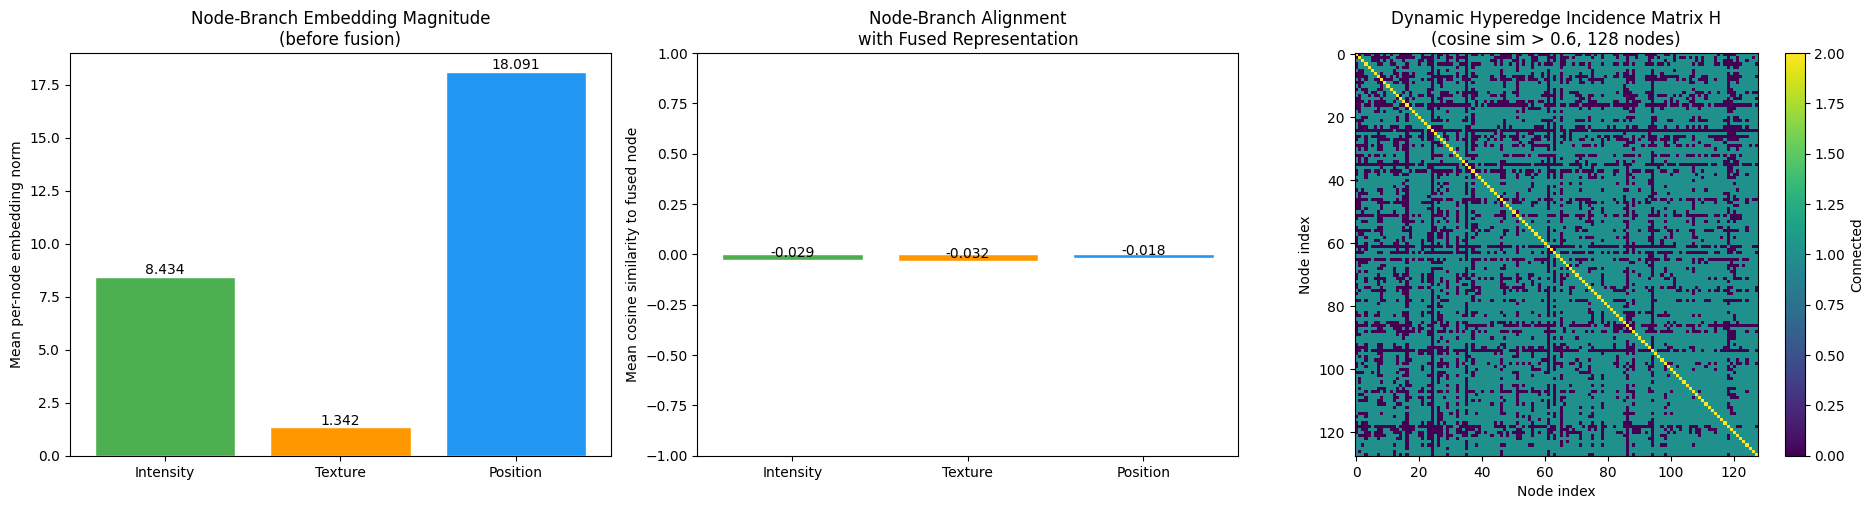

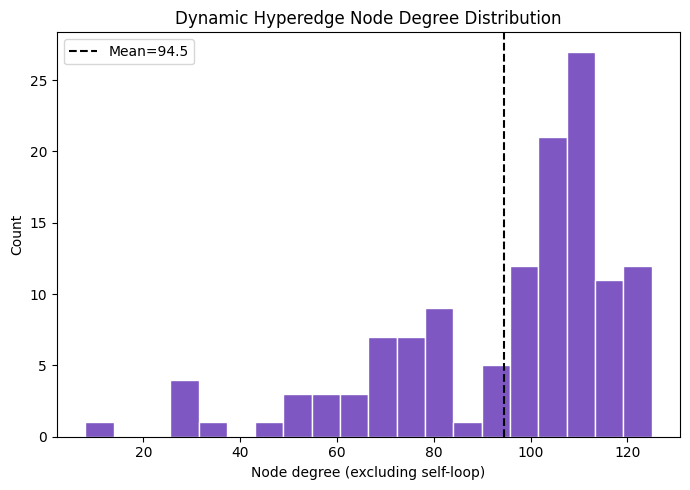

Branch embedding norms  : {'Intensity': 8.4341, 'Texture': 1.3416, 'Position': 18.0906}
Branch-fused cosine sim : {'Intensity': -0.0286, 'Texture': -0.0321, 'Position': -0.0175}
Mean node degree        : 94.55 (of 127 possible)
Saved node_branch_and_hyperedge_matrix.png and hyperedge_degree_distribution.png


In [18]:
model.eval()
sample_imgs, sample_masks = next(iter(test_loader))
sample_imgs = sample_imgs.to(DEVICE)

with torch.no_grad():
    f0, f1, f2, f3 = model.encoder(sample_imgs)
    f3 = model.bottleneck(f3)
    int_n = model.int_nodes(sample_imgs)
    tex_n = model.tex_nodes(f0)
    pos_n = model.pos_nodes(sample_imgs.device).expand(sample_imgs.shape[0], -1, -1)
    fused = model.node_fuse(torch.cat([int_n, tex_n, pos_n], dim=-1))
    H = build_dynamic_hyperedges(fused)

# --- Branch contribution: mean embedding norm + cosine alignment with fused output ---
branches = {"Intensity": int_n, "Texture": tex_n, "Position": pos_n}
branch_norms = {k: v.norm(dim=-1).mean().item() for k, v in branches.items()}
branch_cos = {
    k: F.cosine_similarity(v, fused, dim=-1).mean().item()
    for k, v in branches.items()
}

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

names = list(branches.keys())
colors = ["#4CAF50", "#FF9800", "#2196F3"]

axes[0].bar(names, [branch_norms[n] for n in names], color=colors, edgecolor="white")
axes[0].set_ylabel("Mean per-node embedding norm")
axes[0].set_title("Node-Branch Embedding Magnitude\n(before fusion)")
for i, n in enumerate(names):
    axes[0].text(i, branch_norms[n], f"{branch_norms[n]:.3f}", ha="center", va="bottom")

axes[1].bar(names, [branch_cos[n] for n in names], color=colors, edgecolor="white")
axes[1].set_ylabel("Mean cosine similarity to fused node")
axes[1].set_title("Node-Branch Alignment\nwith Fused Representation")
axes[1].set_ylim(-1, 1)
for i, n in enumerate(names):
    axes[1].text(i, branch_cos[n], f"{branch_cos[n]:.3f}", ha="center", va="bottom")

H_np = H.cpu().numpy()
im = axes[2].imshow(H_np, cmap="viridis")
axes[2].set_title(f"Dynamic Hyperedge Incidence Matrix H\n(cosine sim > {HE_THRESHOLD}, {NUM_PATCHES} nodes)")
axes[2].set_xlabel("Node index")
axes[2].set_ylabel("Node index")
plt.colorbar(im, ax=axes[2], label="Connected")

plt.tight_layout()
plt.savefig("node_branch_and_hyperedge_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

degree = H_np.sum(-1) - 1   # exclude self-loop
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.hist(degree, bins=20, color="#7E57C2", edgecolor="white")
ax2.axvline(degree.mean(), color="black", linestyle="--", label=f"Mean={degree.mean():.1f}")
ax2.set_xlabel("Node degree (excluding self-loop)")
ax2.set_ylabel("Count")
ax2.set_title("Dynamic Hyperedge Node Degree Distribution")
ax2.legend()
plt.tight_layout()
plt.savefig("hyperedge_degree_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print("Branch embedding norms  :", {k: round(v, 4) for k, v in branch_norms.items()})
print("Branch-fused cosine sim :", {k: round(v, 4) for k, v in branch_cos.items()})
print(f"Mean node degree        : {degree.mean():.2f} (of {NUM_PATCHES - 1} possible)")
print("Saved node_branch_and_hyperedge_matrix.png and hyperedge_degree_distribution.png")


## 19. Hypergraph Visualization

Two figures for the paper:

**(a) Spatial dynamic-hyperedge overlay** -- the model's actual graph nodes projected back onto a real wound image, using the same normalised grid-coordinate construction as `PositionNodeExtractor`, with real edges drawn from the dynamic cosine-similarity incidence matrix computed for that image.

**(b) Pipeline schematic** -- a clean diagram of how the three node-feature branches are fused and turned into a dynamic hypergraph for the Methodology section, independent of any specific image.


In [19]:
# --- Recover node spatial positions in image coordinates (mirrors PositionNodeExtractor) ---
n_side = int(NUM_PATCHES ** 0.5)
ys_grid = torch.linspace(0, 1, n_side)
xs_grid = torch.linspace(0, 1, n_side)
gy, gx = torch.meshgrid(ys_grid, xs_grid, indexing="ij")
coords = torch.stack([gx.flatten(), gy.flatten()], dim=-1)   # [n_side*n_side, 2]
if coords.shape[0] < NUM_PATCHES:
    idx = torch.linspace(0, coords.shape[0] - 1, NUM_PATCHES).long()
    coords = coords[idx]

node_px_x = (coords[:, 0].numpy() * IMG_SIZE)
node_px_y = (coords[:, 1].numpy() * IMG_SIZE)

print(f"Grid size: {n_side}x{n_side} ({n_side*n_side} raw positions -> {NUM_PATCHES} nodes)")


Grid size: 11x11 (121 raw positions -> 128 nodes)


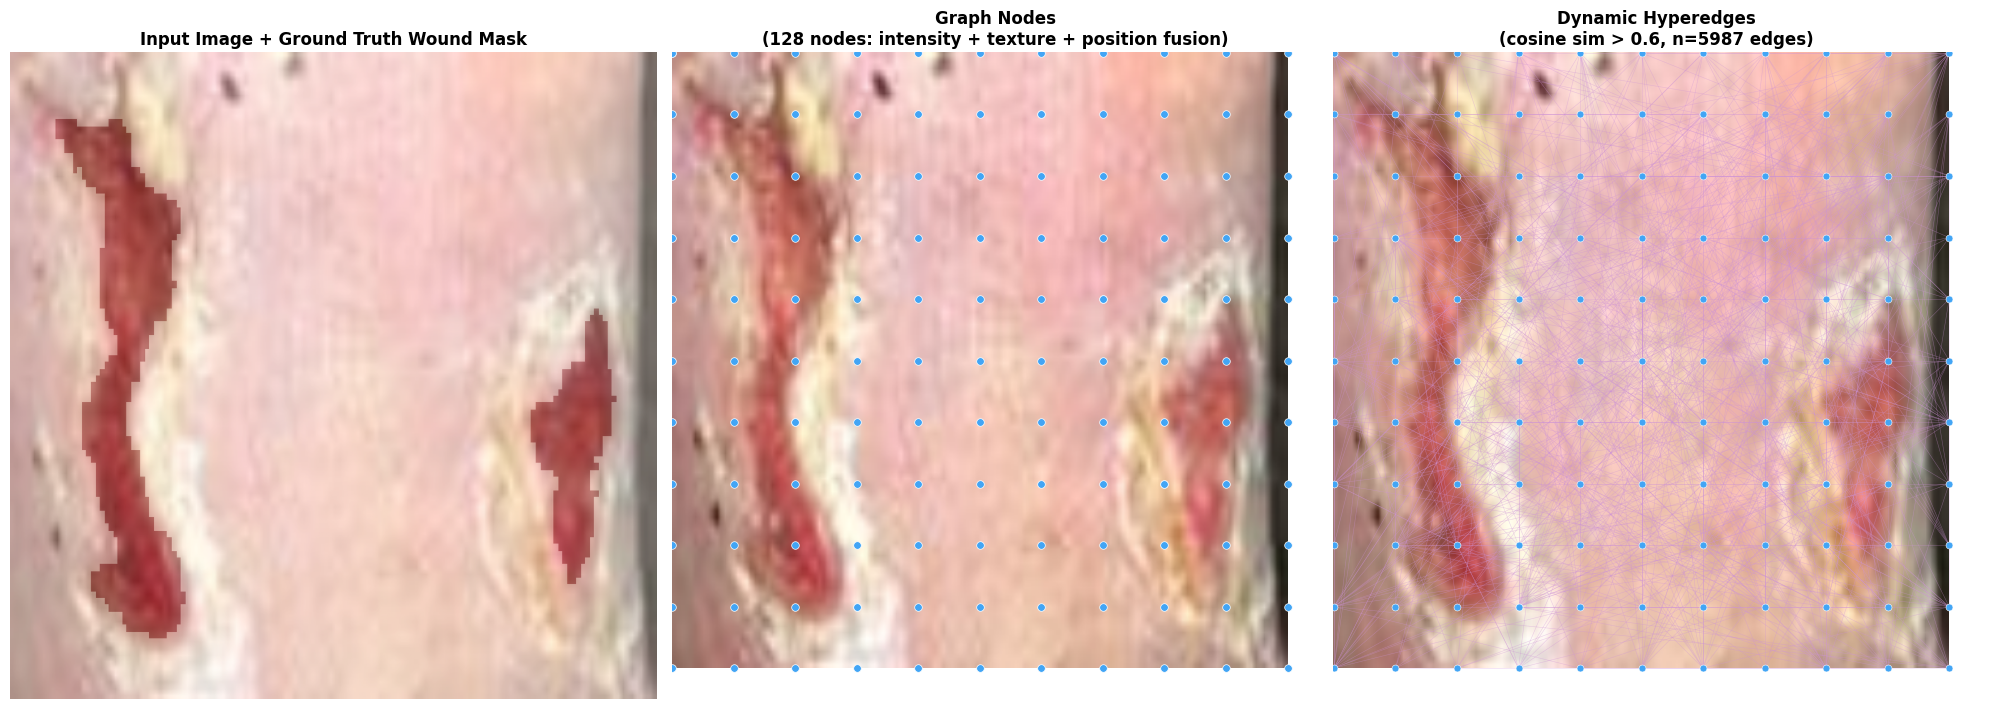

Saved hypergraph_spatial_overlay_m2.png


In [20]:
# --- Pick a representative test image (clear wound boundary, not too small) ---
model.load_state_dict(torch.load("best_model_model2.pth", map_location=DEVICE))
model.eval()

viz_img, viz_mask = None, None
for imgs, masks in test_loader:
    if masks[0].sum() > 500:   # reasonably sized wound for a clear figure
        viz_img, viz_mask = imgs[0], masks[0]
        break

img_np_viz = denorm(viz_img)
mask_np_viz = viz_mask[0].numpy()

with torch.no_grad():
    viz_batch = viz_img.unsqueeze(0).to(DEVICE)
    f0, f1, f2, f3 = model.encoder(viz_batch)
    f3 = model.bottleneck(f3)
    int_n = model.int_nodes(viz_batch)
    tex_n = model.tex_nodes(f0)
    pos_n = model.pos_nodes(viz_batch.device).expand(1, -1, -1)
    fused_viz = model.node_fuse(torch.cat([int_n, tex_n, pos_n], dim=-1))
    H_viz = build_dynamic_hyperedges(fused_viz).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(img_np_viz)
axes[0].imshow(mask_np_viz, cmap="Reds", alpha=0.3)
axes[0].set_title("Input Image + Ground Truth Wound Mask", fontsize=12, fontweight="bold")
axes[0].axis("off")

axes[1].imshow(img_np_viz)
axes[1].scatter(node_px_x, node_px_y, c="#42A5F5", s=30, edgecolors="white", linewidths=0.5, zorder=3)
axes[1].set_title(f"Graph Nodes\n({NUM_PATCHES} nodes: intensity + texture + position fusion)",
                   fontsize=12, fontweight="bold")
axes[1].axis("off")

axes[2].imshow(img_np_viz)
ii, jj = np.where(np.triu(H_viz, k=1) > 0)
max_edges = 600
if len(ii) > max_edges:
    sel = np.random.default_rng(SEED).choice(len(ii), max_edges, replace=False)
    ii, jj = ii[sel], jj[sel]
for a, b in zip(ii, jj):
    axes[2].plot([node_px_x[a], node_px_x[b]], [node_px_y[a], node_px_y[b]],
                 color="#CE93D8", linewidth=0.4, alpha=0.4, zorder=2)
axes[2].scatter(node_px_x, node_px_y, c="#42A5F5", s=25, edgecolors="white", linewidths=0.4, zorder=3)
n_edges = int((H_viz.sum() - np.trace(H_viz)) / 2)
axes[2].set_title(f"Dynamic Hyperedges\n(cosine sim > {HE_THRESHOLD}, n={n_edges} edges)",
                   fontsize=12, fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
plt.savefig("hypergraph_spatial_overlay_m2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_spatial_overlay_m2.png")


### 19b. Node-Fusion and Dynamic Hypergraph Pipeline Schematic

A layout-based diagram, independent of any specific image, showing how the three node-feature branches are fused and turned into a dynamic hypergraph via thresholded cosine similarity, then refined by the HGNN before decoding. This is the figure to put in the Methodology section to *explain* the construction; the spatial overlay above goes in Results to *prove* it works on real data.


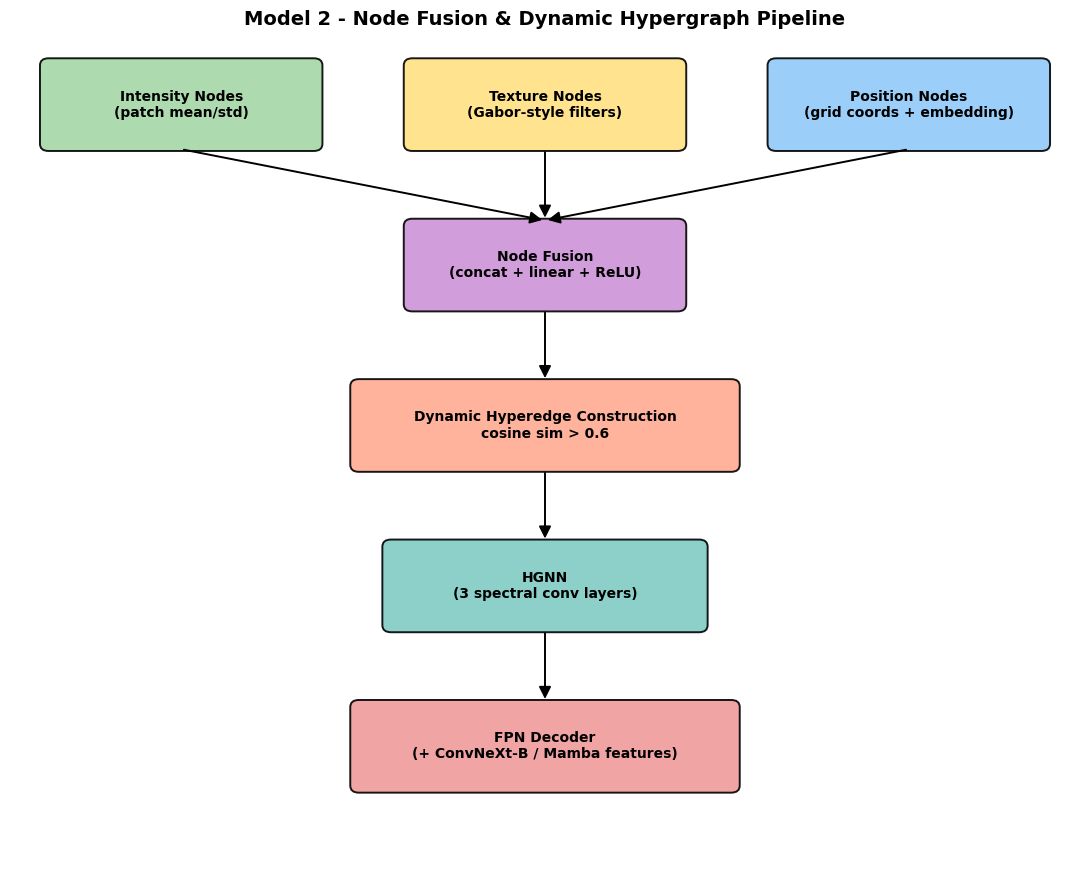

Saved hypergraph_pipeline_schematic_m2.png


In [21]:
import matplotlib.patches as mpatches_schem
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 9))

def draw_box(ax, xy, w, h, text, color, fontsize=10):
    box = FancyBboxPatch(xy, w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                          linewidth=1.4, edgecolor="black", facecolor=color, alpha=0.9)
    ax.add_patch(box)
    ax.text(xy[0] + w / 2, xy[1] + h / 2, text, ha="center", va="center",
            fontsize=fontsize, fontweight="bold", wrap=True)

def draw_arrow(ax, start, end):
    arr = FancyArrowPatch(start, end, arrowstyle="-|>", mutation_scale=18,
                           linewidth=1.4, color="black")
    ax.add_patch(arr)

# Branch boxes
branch_y = 8.2
draw_box(ax, (0.3, branch_y), 2.6, 1.0, "Intensity Nodes\n(patch mean/std)", "#A5D6A7")
draw_box(ax, (3.7, branch_y), 2.6, 1.0, "Texture Nodes\n(Gabor-style filters)", "#FFE082")
draw_box(ax, (7.1, branch_y), 2.6, 1.0, "Position Nodes\n(grid coords + embedding)", "#90CAF9")

# Fusion box
draw_box(ax, (3.7, 6.4), 2.6, 1.0, "Node Fusion\n(concat + linear + ReLU)", "#CE93D8")
for x0 in (1.6, 5.0, 8.4):
    draw_arrow(ax, (x0, branch_y), (5.0, 7.4))

# Dynamic hyperedge box
draw_box(ax, (3.2, 4.6), 3.6, 1.0, f"Dynamic Hyperedge Construction\ncosine sim > {HE_THRESHOLD}", "#FFAB91")
draw_arrow(ax, (5.0, 6.4), (5.0, 5.6))

# HGNN box
draw_box(ax, (3.5, 2.8), 3.0, 1.0, "HGNN\n(3 spectral conv layers)", "#80CBC4")
draw_arrow(ax, (5.0, 4.6), (5.0, 3.8))

# Decoder box
draw_box(ax, (3.2, 1.0), 3.6, 1.0, "FPN Decoder\n(+ ConvNeXt-B / Mamba features)", "#EF9A9A")
draw_arrow(ax, (5.0, 2.8), (5.0, 2.0))

ax.set_xlim(0, 10)
ax.set_ylim(0, 9.5)
ax.axis("off")
ax.set_title("Model 2 - Node Fusion & Dynamic Hypergraph Pipeline", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("hypergraph_pipeline_schematic_m2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved hypergraph_pipeline_schematic_m2.png")
